In [2]:
# combine all 11 XQuAD-R files into one single CSV + Parquet file.
# files: ar.json,de.json,el.json,en.json,es.json,hi.json,ru.json,th.json,tr.json,vi.json,zh.json exist in /content

!pip install -q pandas pyarrow nltk tqdm
import json, os, re
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import nltk
nltk.download('punkt')

# CONFIG
INPUT_DIR = "/content"
OUT_DIR = "/content/xquad_r_singlefile"
os.makedirs(OUT_DIR, exist_ok=True)
LANGS = ["ar","de","el","en","es","hi","ru","th","tr","vi","zh"]
OUT_CSV = os.path.join(OUT_DIR, "xquad_r_all.csv")
OUT_PARQUET = os.path.join(OUT_DIR, "xquad_r_all.parquet")


def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def safe_sent_tokenize(text):
    try:
        sents = nltk.sent_tokenize(text)
        sents = [s.strip() for s in sents if s.strip()]
        if len(sents) == 0:
            raise Exception("empty")
        return sents
    except Exception:
        parts = [p.strip() for p in re.split(r'(?<=[\.\?\!])\s+', text) if p.strip()]
        if not parts:
            return [text.strip()]
        return parts

def make_doc_id(lang, a_idx, p_idx, s_idx=None):
    return f"{lang}-a{a_idx}-p{p_idx}" + (f"-s{s_idx}" if s_idx is not None else "")

rows = []

for lang in LANGS:
    fname = os.path.join(INPUT_DIR, f"{lang}.json")
    if not os.path.exists(fname):
        print(f"[WARN] file missing: {fname} -> skipping {lang}")
        continue
    data = load_json(fname)
    for a_idx, article in enumerate(data.get("data", [])):
        title = article.get("title", "")
        for p_idx, para in enumerate(article.get("paragraphs", [])):
            para_ctx = para.get("context", "")
            sentences = para.get("sentences") or safe_sent_tokenize(para_ctx)

            sent_offsets = []
            running = 0
            for s in sentences:

                find_idx = para_ctx.find(s, running)
                if find_idx == -1:

                    find_idx = para_ctx.find(s)
                if find_idx == -1:

                    find_idx = running
                sent_offsets.append((find_idx, find_idx + len(s)))
                running = find_idx + len(s)

            for qa in para.get("qas", []):
                qid = qa.get("id")
                q_text = qa.get("question", "").strip()
                answers = qa.get("answers", [])
                answer_text = answers[0].get("text") if answers else None
                answer_start_paragraph = answers[0].get("answer_start") if (answers and 'answer_start' in answers[0]) else None

                matched_sent_idx = None
                matched_sent_span = None
                if answer_text:
                    for s_idx, s_text in enumerate(sentences):
                        if answer_text in s_text:
                            matched_sent_idx = s_idx

                            sent_start_in_para = sent_offsets[s_idx][0]
                            rel_start = s_text.index(answer_text)
                            matched_sent_span = (sent_start_in_para + rel_start, sent_start_in_para + rel_start + len(answer_text))
                            break

                    if matched_sent_idx is None and isinstance(answer_start_paragraph, int):

                        for s_idx, (s_start, s_end) in enumerate(sent_offsets):
                            if s_start <= answer_start_paragraph < s_end:
                                matched_sent_idx = s_idx

                                matched_sent_span = (answer_start_paragraph, answer_start_paragraph + (len(answer_text) if answer_text else 0))
                                break

                if matched_sent_idx is not None:
                    context_type = "sentence"
                    context_text = sentences[matched_sent_idx]
                    pos_doc_id = make_doc_id(lang, a_idx, p_idx, matched_sent_idx)
                    sent_idx_val = matched_sent_idx
                else:
                    # fallback to paragraph-level context
                    context_type = "paragraph"
                    context_text = para_ctx
                    pos_doc_id = make_doc_id(lang, a_idx, p_idx, None)
                    sent_idx_val = None

                row = {
                    "qid": qid,
                    "lang": lang,
                    "title": title,
                    "article_idx": a_idx,
                    "para_idx": p_idx,
                    "sent_idx": sent_idx_val,
                    "pos_doc_id": pos_doc_id,
                    "question": q_text,
                    "answer_text": answer_text,
                    "answer_start_in_para": answer_start_paragraph,
                    "context_type": context_type,
                    "context_text": context_text,
                    "orig_context": para_ctx
                }
                rows.append(row)

# Create dataframe
df = pd.DataFrame(rows)
print("Total QA rows:", len(df))
# Reorder columns sensibly
cols = ["qid","lang","question","answer_text","answer_start_in_para","context_type","context_text","pos_doc_id","title","article_idx","para_idx","sent_idx","orig_context"]
df = df[cols]


df.to_csv(OUT_CSV, index=False, encoding="utf-8")

df.to_parquet(OUT_PARQUET, index=False)

print("Wrote:\n -", OUT_CSV, "\n -", OUT_PARQUET)
print("Sample rows per language:")
print(df.groupby("lang").size().sort_values(ascending=False).head(20))

def top_k_questions(lang='en', k=10):
    sub = df[df['lang']==lang]
    print(f"Total {len(sub)} questions for {lang}. Showing top {k}:")
    display(sub[['qid','question']].head(k))

def sample_question(qid):
    r = df[df['qid']==qid]
    if r.empty:
        print("qid not found")
        return
    display(r.T)

top_k_questions('en', 10)
sample_question(df['qid'].iloc[0])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Total QA rows: 13090
Wrote:
 - /content/xquad_r_singlefile/xquad_r_all.csv 
 - /content/xquad_r_singlefile/xquad_r_all.parquet
Sample rows per language:
lang
ar    1190
de    1190
el    1190
en    1190
es    1190
hi    1190
ru    1190
th    1190
tr    1190
vi    1190
zh    1190
dtype: int64
Total 1190 questions for en. Showing top 10:


,qid,question
3570,56beb4343aeaaa14008c925b,How many points did the Panthers defense surre...
3571,56beb4343aeaaa14008c925c,How many career sacks did Jared Allen have?
3572,56beb4343aeaaa14008c925d,How many tackles did Luke Kuechly register?
3573,56beb4343aeaaa14008c925e,How many balls did Josh Norman intercept?
3574,56beb4343aeaaa14008c925f,Who registered the most sacks on the team this...
3575,56d6f3500d65d21400198290,How many interceptions are the Panthers defens...
3576,56d6f3500d65d21400198291,Who led the Panthers in sacks?
3577,56d6f3500d65d21400198292,How many Panthers defense players were selecte...
3578,56d6f3500d65d21400198293,How many forced fumbles did Thomas Davis have?
3579,56d6f3500d65d21400198294,Which player had the most interceptions for th...


,0,1190,2380,3570,4760,5950,7140,8330,9520,10710,11900
qid,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b,56beb4343aeaaa14008c925b
lang,ar,de,el,en,es,hi,ru,th,tr,vi,zh
question,كم نقطة تخلى عنها دفاع البانثرز؟,Wie viele Punkte gab die Verteidigung der Pant...,Πόσους πόντους παρέδωσε η άμυνα των Πάνθερς;,How many points did the Panthers defense surre...,¿Cuántos puntos dejaron escapar en defensa los...,पैंथर्स डिफ़ेंस ने कितने अंक दिए?,Сколько очков уступила защита Пэнтерс?,ทีมรับของแพนเธอร์สยอมแพ้ที่คะแนนเท่าไร,Panthers savunması kaç sayı bırakmıştır?,Đội thủ Panthers đã thua bao nhiêu điểm?,黑豹队的防守丢了多少分？
answer_text,308,308,308,308,308,308,308,308,308,308,308
answer_start_in_para,29,38,43,34,133,35,31,33,66,30,10
context_type,sentence,sentence,sentence,sentence,sentence,sentence,sentence,sentence,sentence,sentence,sentence
context_text,لم يتخلى فريق بانثرز سوى عن 308 نقطة، ليحتل ا...,Die Verteidigung der Panthers gab nur 308 Punk...,Η άμυνα των Καρολίνα Πάνθερς παρέδωσε μόνο 308...,"The Panthers defense gave up just 308 points, ...","﻿Los Panthers, que además de liderar las inter...",पैंथर्स की डिफ़ेन्स ने लीग में केवल 308 अंक दिए...,"﻿Защита Пэнтерс уступила всего 308 очков, заня...",﻿ทีมรับของแพนเธอร์สถอดใจที่คะแนน 308 ได้อันดับ...,﻿Panthers savunması ligdeki derecesi altıncı s...,"Đội thủ của Panthers chỉ thua 308 điểm, đứng t...",黑豹队的防守只丢了 308分，在联赛中排名第六，同时也以 24 次拦截领先国家橄榄球联盟 (...
pos_doc_id,ar-a0-p0-s0,de-a0-p0-s0,el-a0-p0-s0,en-a0-p0-s0,es-a0-p0-s0,hi-a0-p0-s0,ru-a0-p0-s0,th-a0-p0-s0,tr-a0-p0-s0,vi-a0-p0-s0,zh-a0-p0-s0
title,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50,Super_Bowl_50
article_idx,0,0,0,0,0,0,0,0,0,0,0


In [1]:
# Cell 1: Install and imports
!pip install -q sentence-transformers transformers pandas torch

import os, time, random, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator

os.environ["WANDB_DISABLED"] = "true"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CSV_PATH = 'xquad_r_all.csv'
MODEL_NAME = 'bert-base-multilingual-cased'
OUTPUT_ROOT = Path('output/finetune-mbert-xquadr')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [2]:
# Cell 2: Load dataset and create train/dev split + evaluation artifacts
import pandas as pd, pickle
from pathlib import Path

csv_path = Path(CSV_PATH)
if not csv_path.exists():
    try:
        from google.colab import files
        print(f"Upload your CSV named '{CSV_PATH}' (it must contain columns qid, question, context_text, pos_doc_id).")
        uploaded = files.upload()
        if len(uploaded) > 0:
            first = list(uploaded.keys())[0]
            Path(first).rename(csv_path)
            print(f"Saved uploaded '{first}' as '{csv_path}'.")
    except Exception as e:
        raise SystemExit(f"{csv_path} not found and automatic upload failed: {e}")

df = pd.read_csv(csv_path)
required_cols = {'qid','question','context_text','pos_doc_id'}
if not required_cols.issubset(set(df.columns)):
    raise SystemExit(f"CSV must contain columns {required_cols}. Found: {list(df.columns)}")

df = df[['qid','question','context_text','pos_doc_id']].dropna()
df['qid'] = df['qid'].astype(str)
df['question'] = df['question'].astype(str)
df['context_text'] = df['context_text'].astype(str)
df['pos_doc_id'] = df['pos_doc_id'].astype(str)

print("Loaded rows:", len(df), "unique qids:", df['qid'].nunique())

DEV_FRAC = 0.10
dev_df = df.sample(frac=DEV_FRAC, random_state=SEED).reset_index(drop=True)
train_df = df.drop(dev_df.index).reset_index(drop=True)
print("Train rows:", len(train_df), "Dev rows:", len(dev_df))

corpus_df = df[['pos_doc_id','context_text']].drop_duplicates().set_index('pos_doc_id')
corpus = corpus_df['context_text'].to_dict()
queries = dev_df[['qid','question']].drop_duplicates().set_index('qid')['question'].to_dict()
relevant_docs = dev_df.groupby('qid')['pos_doc_id'].apply(lambda x:set(x.astype(str))).to_dict()

pickle_path = OUTPUT_ROOT / 'data_artifacts.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump({
        'df': df,
        'train_df': train_df,
        'dev_df': dev_df,
        'corpus': corpus,
        'queries': queries,
        'relevant_docs': relevant_docs
    }, f)
print(f"Saved dataset artifacts to {pickle_path}")


Loaded rows: 13090 unique qids: 1190
Train rows: 11781 Dev rows: 1309
Saved dataset artifacts to output/finetune-mbert-xquadr/data_artifacts.pkl


In [3]:
# === Stage A ===
import pickle, time, torch, os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator


torch.set_num_threads(1)

ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
assert ART_PATH.exists(), "Run Cell 2 first."

with open(ART_PATH, 'rb') as f:
    artifacts = pickle.load(f)
train_df = artifacts['train_df']
dev_df = artifacts['dev_df']
corpus = artifacts['corpus']
queries = artifacts['queries']
relevant_docs = artifacts['relevant_docs']

print("Train rows:", len(train_df))

class LazyTrainDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return InputExample(texts=[str(row['question']), str(row['context_text'])])

train_dataset = LazyTrainDataset(train_df)

# stageA path
stageA_dir = OUTPUT_ROOT / 'stageA'
stageA_dir.mkdir(parents=True, exist_ok=True)

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100,1000],
    show_progress_bar=False,
    batch_size=64
)

if (stageA_dir / 'config.json').exists() or any(stageA_dir.glob('*.pt')):
    print("Stage A model already exists; loading.")
    stageA_model = SentenceTransformer(str(stageA_dir))
else:
    model = SentenceTransformer(MODEL_NAME)

    try:
        model.max_seq_length = 64
    except Exception:
        pass


    batch_candidates = [8,4,2,1]
    trained = False
    for b in batch_candidates:
        print(f"Trying Stage A with batch_size={b}")
        train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=b, num_workers=0, pin_memory=False)
        train_loss = losses.MultipleNegativesRankingLoss(model)
        num_epochs = 1           
        warmup_steps = max(1, int(len(train_dataloader) * num_epochs * 0.1))
        try:
            model.fit(
                train_objectives=[(train_dataloader, train_loss)],
                evaluator=evaluator,
                epochs=num_epochs,
                warmup_steps=warmup_steps,
                evaluation_steps=999999,
                output_path=str(stageA_dir),
                save_best_model=True,
                use_amp=False
            )
            trained = True
            print("Stage A training finished with batch", b)
            break
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("OOM with batch", b, "-- trying smaller batch.")
                try:
                    torch.cuda.empty_cache()
                except Exception:
                    pass
                time.sleep(3)
                continue
            else:
                raise
    if not trained:
        raise SystemExit("Stage A failed on all tiny batch sizes. Consider a larger machine or using a smaller model.")

    stageA_model = SentenceTransformer(str(stageA_dir))

print("Stage A model ready at:", stageA_dir)


Train rows: 11781


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

Trying Stage A with batch_size=8


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Xquad-r-dev Cosine Accuracy@1,Xquad-r-dev Cosine Accuracy@3,Xquad-r-dev Cosine Accuracy@5,Xquad-r-dev Cosine Accuracy@10,Xquad-r-dev Cosine Precision@1,Xquad-r-dev Cosine Precision@3,Xquad-r-dev Cosine Precision@5,Xquad-r-dev Cosine Precision@10,Xquad-r-dev Cosine Recall@1,Xquad-r-dev Cosine Recall@3,Xquad-r-dev Cosine Recall@5,Xquad-r-dev Cosine Recall@10,Xquad-r-dev Cosine Ndcg@10,Xquad-r-dev Cosine Mrr@10,Xquad-r-dev Cosine Map@100,Xquad-r-dev Cosine Map@1000
1473,0.041800,No log,0.615293,0.782557,0.838710,0.888889,0.615293,0.260852,0.167981,0.090084,0.473258,0.606710,0.652907,0.691975,0.622049,0.711377,0.559330,0.560436


Stage A training finished with batch 8
Stage A model ready at: output/finetune-mbert-xquadr/stageA


In [4]:
# Cell 5: hard-negative mining
import pickle, numpy as np, time, os
from pathlib import Path
from sentence_transformers import SentenceTransformer, util, InputExample

ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
assert Path(ART_PATH).exists(), "Run Cell 2 (data artifacts) already."

with open(ART_PATH,'rb') as f:
    artifacts = pickle.load(f)

corpus = artifacts['corpus']
train_df = artifacts['train_df']

stageA_dir = OUTPUT_ROOT / 'stageA'
assert Path(stageA_dir).exists(), "Stage A model missing — run Stage A first."

model = SentenceTransformer(str(stageA_dir))
try:
    model.max_seq_length = 64
except Exception:
    pass


corpus_items = list(corpus.items())
corpus_ids = [c[0] for c in corpus_items]
corpus_texts = [c[1] for c in corpus_items]
N = len(corpus_texts)
emb_dim = model.get_sentence_embedding_dimension()
print("Corpus size:", N, "embedding dim:", emb_dim)

emb_path = OUTPUT_ROOT / 'corpus_embeddings.memmap'
hard_neg_path = OUTPUT_ROOT / 'hard_negatives.pkl'
triplets_path = OUTPUT_ROOT / 'triplet_examples.pkl'

if not emb_path.exists():
    print("Encoding corpus to disk (memmap). This will write a file:", emb_path)
    enc_batch = 32
    fp = np.memmap(str(emb_path), dtype='float32', mode='w+', shape=(N, emb_dim))
    for i in range(0, N, enc_batch):
        batch_texts = corpus_texts[i:i+enc_batch]
        batch_emb = model.encode(batch_texts, batch_size=len(batch_texts), show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)
        fp[i:i+len(batch_emb), :] = batch_emb.astype('float32')
        fp.flush()
        print(f"Encoded {min(i+enc_batch, N)}/{N}")
    del fp
else:
    print("Found existing corpus embeddings memmap:", emb_path)

# 2) If triplets already exist, skip mining
if Path(triplets_path).exists():
    print("Triplet examples already exist at:", triplets_path, "- skipping mining.")
else:
    print("Performing chunked semantic search to mine hard negatives (no full-RAM load).")

    emb_fp = np.memmap(str(emb_path), dtype='float32', mode='r', shape=(N, emb_dim))

    train_q_map = train_df[['qid','question']].drop_duplicates().set_index('qid')['question'].to_dict()
    train_qids = list(train_q_map.keys())
    Q = len(train_qids)
    print("Train queries count for mining:", Q)

    q_batch = 32
    query_embs_list = []
    for i in range(0, Q, q_batch):
        texts = [train_q_map[q] for q in train_qids[i:i+q_batch]]
        emb = model.encode(texts, batch_size=len(texts), show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)
        query_embs_list.append(emb)
        print(f"Encoded queries {min(i+q_batch, Q)}/{Q}")
    query_embs = np.vstack(query_embs_list)

    # We'll compute top_k scores by scanning the corpus in chunks
    top_k = 20   # top_k candidates per query to consider; we'll then select top-3 hard negatives excluding positives
    topk_keep = 10  # internal keep size per query while scanning

    # Initialize arrays for storing best candidates per query
    topk_scores = np.full((Q, topk_keep), -1e9, dtype='float32')
    topk_idxs = np.full((Q, topk_keep), -1, dtype='int32')

    chunk_size = 512   # tune to 256 if you need less RAM
    for start in range(0, N, chunk_size):
        end = min(N, start + chunk_size)
        chunk = np.memmap(str(emb_path), dtype='float32', mode='r', shape=(N, emb_dim))[start:end]  # shape (chunk_len, dim)
        # process queries in sub-batches to keep RAM low
        q_sub = 128
        for qi in range(0, Q, q_sub):
            qend = min(Q, qi + q_sub)
            q_emb = query_embs[qi:qend]   # shape (q_sub, dim)
            # compute similarities: (q_sub x chunk_len) using dot since we normalized
            sims = np.matmul(q_emb, chunk.T)  # shape (q_sub, chunk_len)
            for local_i in range(sims.shape[0]):
                global_i = qi + local_i
                chunk_scores = sims[local_i].astype('float32')  # length chunk_len
                # combine old and new scores and indices
                combined_scores = np.concatenate([topk_scores[global_i], chunk_scores])
                combined_idxs = np.concatenate([topk_idxs[global_i], np.arange(start, end, dtype='int32')])
                # take top 'topk_keep'
                if combined_scores.size <= topk_keep:
                    order = np.argsort(-combined_scores)
                else:
                    order = np.argpartition(-combined_scores, topk_keep-1)[:topk_keep]
                    order = order[np.argsort(-combined_scores[order])]
                topk_scores[global_i] = combined_scores[order]
                topk_idxs[global_i] = combined_idxs[order]
        print(f"Scanned corpus chunk {start}:{end}")

    # Map back to doc ids and filter positives
    idx_to_docid = {idx: docid for idx, docid in enumerate(corpus_ids)}
    pos_map_train = train_df.groupby('qid')['pos_doc_id'].apply(lambda x:set(x.astype(str))).to_dict()

    hard_negatives = {}
    for qi, qid in enumerate(train_qids):
        order = np.argsort(-topk_scores[qi])
        negs = []
        for o in order:
            idx = int(topk_idxs[qi][o])
            if idx < 0:
                continue
            docid = idx_to_docid[idx]
            if qid in pos_map_train and docid in pos_map_train[qid]:
                continue
            negs.append(docid)
            if len(negs) >= 3:   # final keep top-3 hard negatives
                break
        if negs:
            hard_negatives[qid] = negs

    # Save hard negatives
    with open(hard_neg_path,'wb') as f:
        pickle.dump(hard_negatives, f)
    print("Saved hard_negatives for", len(hard_negatives), "queries to", hard_neg_path)

    # Create triplet InputExamples and save
    triplet_examples = []
    pos_text_map = corpus.copy()
    for qid, negs in hard_negatives.items():
        pos_ids = train_df[train_df['qid'] == qid]['pos_doc_id'].unique()
        if len(pos_ids) == 0:
            continue
        pos_id = str(pos_ids[0])
        pos_text = pos_text_map.get(pos_id)
        if pos_text is None:
            continue
        q_text = train_q_map[qid]
        for neg_id in negs:
            neg_text = pos_text_map.get(neg_id)
            if neg_text is None:
                continue
            triplet_examples.append(InputExample(texts=[q_text, pos_text, neg_text]))

    with open(triplets_path,'wb') as f:
        pickle.dump(triplet_examples, f)
    print("Saved triplet examples to", triplets_path, "count =", len(triplet_examples))


Corpus size: 8408 embedding dim: 768
Encoding corpus to disk (memmap). This will write a file: output/finetune-mbert-xquadr/corpus_embeddings.memmap
Encoded 32/8408
Encoded 64/8408
Encoded 96/8408
Encoded 128/8408
Encoded 160/8408
Encoded 192/8408
Encoded 224/8408
Encoded 256/8408
Encoded 288/8408
Encoded 320/8408
Encoded 352/8408
Encoded 384/8408
Encoded 416/8408
Encoded 448/8408
Encoded 480/8408
Encoded 512/8408
Encoded 544/8408
Encoded 576/8408
Encoded 608/8408
Encoded 640/8408
Encoded 672/8408
Encoded 704/8408
Encoded 736/8408
Encoded 768/8408
Encoded 800/8408
Encoded 832/8408
Encoded 864/8408
Encoded 896/8408
Encoded 928/8408
Encoded 960/8408
Encoded 992/8408
Encoded 1024/8408
Encoded 1056/8408
Encoded 1088/8408
Encoded 1120/8408
Encoded 1152/8408
Encoded 1184/8408
Encoded 1216/8408
Encoded 1248/8408
Encoded 1280/8408
Encoded 1312/8408
Encoded 1344/8408
Encoded 1376/8408
Encoded 1408/8408
Encoded 1440/8408
Encoded 1472/8408
Encoded 1504/8408
Encoded 1536/8408
Encoded 1568/8408
Enc

In [5]:
# === Cell 6: Stage B training (TripletLoss) with evaluator provided ===
import pickle, time, torch
from pathlib import Path
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator

ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
TRIPLETS_PATH = OUTPUT_ROOT / 'triplet_examples.pkl'
STAGEA_DIR = OUTPUT_ROOT / 'stageA'
STAGEB_DIR = OUTPUT_ROOT / 'stageB'

assert Path(ART_PATH).exists(), "Run Cell 2 first (data artifacts)."
assert Path(TRIPLETS_PATH).exists(), "Run Cell 5 to create triplet examples first."
assert Path(STAGEA_DIR).exists(), "Stage A model missing. Run Stage A (Cell 3) first."

# Load artifacts and triplets
with open(ART_PATH,'rb') as f:
    artifacts = pickle.load(f)
corpus = artifacts['corpus']
queries = artifacts['queries']
relevant_docs = artifacts['relevant_docs']

with open(TRIPLETS_PATH,'rb') as f:
    triplet_examples = pickle.load(f)

print("Triplet examples count:", len(triplet_examples))
print("Dev queries for evaluator:", len(queries), "Corpus size:", len(corpus))

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100, 1000],
    show_progress_bar=False,
    batch_size=64
)

# Stage B dir
STAGEB_DIR.mkdir(parents=True, exist_ok=True)

if (STAGEB_DIR / 'config.json').exists() or any(STAGEB_DIR.glob('*.pt')):
    print("Stage B model already exists at", STAGEB_DIR, "- loading and skipping training.")
    final_model = SentenceTransformer(str(STAGEB_DIR))
else:
    # Load Stage A model as initialization
    model_stageB = SentenceTransformer(str(STAGEA_DIR))
    try:
        model_stageB.max_seq_length = 64
    except Exception:
        pass

    batch_candidates = [16, 8, 4, 2]
    trained = False
    for b in batch_candidates:
        try:
            print(f"\nTrying Stage B with batch_size = {b}")
            train_dataloader = DataLoader(triplet_examples, shuffle=True, batch_size=b, num_workers=0, pin_memory=False)
            triplet_loss = losses.TripletLoss(model_stageB, triplet_margin=0.25)
            num_epochs = 2
            warmup_steps = max(1, int(len(train_dataloader) * num_epochs * 0.1))
            model_stageB.fit(
                train_objectives=[(train_dataloader, triplet_loss)],
                evaluator=evaluator,
                epochs=num_epochs,
                warmup_steps=warmup_steps,
                evaluation_steps=999999,
                output_path=str(STAGEB_DIR),
                save_best_model=True,
                use_amp=False
            )
            trained = True
            print("Stage B training completed with batch size", b)
            break
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("OOM with batch", b, "- trying smaller batch")
                try:
                    torch.cuda.empty_cache()
                except Exception:
                    pass
                time.sleep(4)
                continue
            else:
                raise
    if not trained:
        raise SystemExit("Stage B failed with all batch sizes. Consider smaller batches or a larger machine.")

    final_model = SentenceTransformer(str(STAGEB_DIR))

print("Stage B model ready at:", STAGEB_DIR)


Triplet examples count: 3569
Dev queries for evaluator: 837 Corpus size: 8408


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



Trying Stage B with batch_size = 16


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Xquad-r-dev Cosine Accuracy@1,Xquad-r-dev Cosine Accuracy@3,Xquad-r-dev Cosine Accuracy@5,Xquad-r-dev Cosine Accuracy@10,Xquad-r-dev Cosine Precision@1,Xquad-r-dev Cosine Precision@3,Xquad-r-dev Cosine Precision@5,Xquad-r-dev Cosine Precision@10,Xquad-r-dev Cosine Recall@1,Xquad-r-dev Cosine Recall@3,Xquad-r-dev Cosine Recall@5,Xquad-r-dev Cosine Recall@10,Xquad-r-dev Cosine Ndcg@10,Xquad-r-dev Cosine Mrr@10,Xquad-r-dev Cosine Map@100,Xquad-r-dev Cosine Map@1000
224,No log,No log,0.565114,0.732378,0.800478,0.856631,0.565114,0.244126,0.160573,0.086022,0.434130,0.568937,0.622003,0.668439,0.585039,0.663051,0.518668,0.519530
448,No log,No log,0.583035,0.738351,0.804062,0.859020,0.583035,0.246117,0.161290,0.086141,0.450060,0.571426,0.624194,0.669196,0.593722,0.676107,0.529354,0.530190


Stage B training completed with batch size 16
Stage B model ready at: output/finetune-mbert-xquadr/stageB


In [6]:
# Cell 7: Final evaluation of final model and print mAP@100 and mAP@1000
import pickle
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
with open(ART_PATH,'rb') as f:
    artifacts = pickle.load(f)

corpus = artifacts['corpus']
queries = artifacts['queries']
relevant_docs = artifacts['relevant_docs']

stageB_dir = OUTPUT_ROOT / 'stageB'
stageA_dir = OUTPUT_ROOT / 'stageA'

# Prefer Stage B (final), fallback to Stage A if Stage B missing
if Path(stageB_dir).exists() and (stageB_dir / 'config.json').exists():
    model_path = stageB_dir
elif Path(stageA_dir).exists():
    model_path = stageA_dir
else:
    raise SystemExit("No trained model found. Run Stage A (and Stage B) first.")

model = SentenceTransformer(str(model_path))
try:
    model.max_seq_length = 128
except Exception:
    pass

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100, 1000],
    show_progress_bar=True,
    batch_size=64
)

print("Running final evaluation on model:", model_path)
results = evaluator(model, output_path=str(model_path))

# safe print of map metrics
keys = list(results.keys())
k100 = next((k for k in keys if 'map@100' in k.lower()), None)
k1000 = next((k for k in keys if 'map@1000' in k.lower()), None)

if k100 and isinstance(results.get(k100), (int,float)):
    print(f"mAP@100:  {results.get(k100) * 100:.2f}")
else:
    print("mAP@100:", results.get(k100))

if k1000 and isinstance(results.get(k1000), (int,float)):
    print(f"mAP@1000: {results.get(k1000) * 100:.2f}")
else:
    print("mAP@1000:", results.get(k1000))

print("Evaluation finished. Model used:", model_path)
print("Artifacts saved under:", OUTPUT_ROOT)


Running final evaluation on model: output/finetune-mbert-xquadr/stageB


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:45<00:00, 45.68s/it]


mAP@100:  54.15
mAP@1000: 54.24
Evaluation finished. Model used: output/finetune-mbert-xquadr/stageB
Artifacts saved under: output/finetune-mbert-xquadr


In [8]:
# Cell A: Continue / strengthen Stage A (in-batch negatives)
import pickle, time, torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# Paths & checks
ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
STAGEA_DIR = OUTPUT_ROOT / 'stageA'
assert Path(ART_PATH).exists(), "Run Cell 2 to create data artifacts first."
assert Path(STAGEA_DIR).exists(), "Stage A must exist (you said Stage A already completed)."

with open(ART_PATH, 'rb') as f:
    artifacts = pickle.load(f)
train_df = artifacts['train_df']
dev_queries = artifacts['queries']
corpus = artifacts['corpus']
relevant_docs = artifacts['relevant_docs']

# Lazy dataset (same as before)
class LazyTrainDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return InputExample(texts=[str(row['question']), str(row['context_text'])])

train_dataset = LazyTrainDataset(train_df)
print("Train examples:", len(train_dataset))

# evaluator (pass to fit so trainer doesn't error)
evaluator = InformationRetrievalEvaluator(
    queries=dev_queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100,1000],
    show_progress_bar=False,
    batch_size=64
)

# Load existing Stage A model (resume)
model = SentenceTransformer(str(STAGEA_DIR))
# safe seq len
try:
    model.max_seq_length = 128
except Exception:
    pass

# Training knobs (tune if OOM)
num_epochs_stageA = 4              # increased from previous
batch_candidates = [48, 32, 16, 8] 
use_amp = False 

trained = False
for b in batch_candidates:
    try:
        print(f"Attempting to continue Stage A with batch_size={b}, epochs={num_epochs_stageA}")
        train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=b, num_workers=0, pin_memory=False)
        train_loss = losses.MultipleNegativesRankingLoss(model)
        warmup_steps = max(1, int(len(train_dataloader) * num_epochs_stageA * 0.1))
        model.fit(
            train_objectives=[(train_dataloader, train_loss)],
            evaluator=evaluator,
            epochs=num_epochs_stageA,
            warmup_steps=warmup_steps,
            evaluation_steps=999999,   # avoid intermediate eval spikes
            output_path=str(STAGEA_DIR),
            save_best_model=True,
            use_amp=use_amp
        )
        trained = True
        print("Continued Stage A training completed with batch_size=", b)
        break
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("OOM at batch", b, "-> trying smaller batch.")
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass
            time.sleep(4)
            continue
        else:
            raise

if not trained:
    raise SystemExit("Could not continue Stage A with any batch size. Consider lowering batch_candidates.")

# Quick eval after continuation
stageA_model = SentenceTransformer(str(STAGEA_DIR))
print("Evaluating the resumed Stage A model (quick)...")
res = evaluator(stageA_model, output_path=str(STAGEA_DIR))
# print maps safely
keys = list(res.keys())
k100 = next((k for k in keys if 'map@100' in k.lower()), None)
k1000 = next((k for k in keys if 'map@1000' in k.lower()), None)
if k100 and isinstance(res.get(k100), (int,float)):
    print(f"[StageA-resume] mAP@100: {res.get(k100)*100:.2f}")
if k1000 and isinstance(res.get(k1000), (int,float)):
    print(f"[StageA-resume] mAP@1000: {res.get(k1000)*100:.2f}")
print("Saved resumed Stage A model to:", STAGEA_DIR)


Train examples: 11781
Attempting to continue Stage A with batch_size=48, epochs=4


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Xquad-r-dev Cosine Accuracy@1,Xquad-r-dev Cosine Accuracy@3,Xquad-r-dev Cosine Accuracy@5,Xquad-r-dev Cosine Accuracy@10,Xquad-r-dev Cosine Precision@1,Xquad-r-dev Cosine Precision@3,Xquad-r-dev Cosine Precision@5,Xquad-r-dev Cosine Precision@10,Xquad-r-dev Cosine Recall@1,Xquad-r-dev Cosine Recall@3,Xquad-r-dev Cosine Recall@5,Xquad-r-dev Cosine Recall@10,Xquad-r-dev Cosine Ndcg@10,Xquad-r-dev Cosine Mrr@10,Xquad-r-dev Cosine Map@100,Xquad-r-dev Cosine Map@1000
246,No log,No log,0.738351,0.896057,0.946237,0.971326,0.738351,0.300279,0.191398,0.101434,0.574413,0.698845,0.740940,0.771744,0.718573,0.825185,0.657187,0.657989
492,No log,No log,0.774194,0.923536,0.956989,0.972521,0.774194,0.309837,0.193787,0.102748,0.598546,0.719753,0.746575,0.773636,0.735748,0.851831,0.678703,0.679547
738,0.028100,No log,0.802867,0.951016,0.973716,0.985663,0.802867,0.318200,0.196655,0.102987,0.621247,0.737276,0.755575,0.779311,0.751259,0.876881,0.694197,0.694992
984,0.028100,No log,0.806452,0.952210,0.974910,0.986858,0.806452,0.318598,0.197611,0.104062,0.624632,0.740562,0.758065,0.783891,0.755728,0.880240,0.699626,0.700445


Continued Stage A training completed with batch_size= 48
Evaluating the resumed Stage A model (quick)...
[StageA-resume] mAP@100: 69.96
[StageA-resume] mAP@1000: 70.04
Saved resumed Stage A model to: output/finetune-mbert-xquadr/stageA


In [9]:
# Cell B: Stage B re-train with BatchHardTripletLoss (memory-safe)
import pickle, time, torch
from pathlib import Path
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# Paths & checks
ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
TRIPLETS_PATH = OUTPUT_ROOT / 'triplet_examples.pkl'
STAGEA_DIR = OUTPUT_ROOT / 'stageA'
STAGEB_DIR = OUTPUT_ROOT / 'stageB'

assert Path(ART_PATH).exists()
assert Path(TRIPLETS_PATH).exists()
assert Path(STAGEA_DIR).exists()

with open(ART_PATH,'rb') as f:
    artifacts = pickle.load(f)
corpus = artifacts['corpus']
queries = artifacts['queries']
relevant_docs = artifacts['relevant_docs']

with open(TRIPLETS_PATH,'rb') as f:
    triplet_examples = pickle.load(f)

print("Triplets count:", len(triplet_examples))

# evaluator
evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100,1000],
    show_progress_bar=False,
    batch_size=64
)

# If StageB exists, back it up (optional)
if Path(STAGEB_DIR).exists() and (STAGEB_DIR / 'config.json').exists():
    print("Existing StageB found; it will be overwritten if training completes.")

# Load Stage A initialization
model = SentenceTransformer(str(STAGEA_DIR))
try:
    model.max_seq_length = 128
except Exception:
    pass

# Use BatchHardTripletLoss (mines hardest negative inside a batch)
# For BatchHardTripletLoss we need to supply labels/anchor grouping; SentenceTransformers expects embeddings arranged with anchor/positive/negative?
# However BatchHardTripletLoss can operate on batches of triplet triples; we'll use it on the list of triplet InputExamples and a custom miner is not needed here.
from sentence_transformers.losses import BatchHardTripletLoss
# distance metric: "cosine" commonly works
margin = 0.25

batch_candidates = [16, 8, 4, 2]   # small for memory safety
num_epochs_stageB = 4
trained = False

for b in batch_candidates:
    try:
        print(f"\nTrying Stage B with BatchHardTripletLoss and batch_size = {b}")
        train_dataloader = DataLoader(triplet_examples, shuffle=True, batch_size=b, num_workers=0, pin_memory=False)
        # BatchHardTripletLoss will look for labels; to use it with triplet InputExamples we can use it directly as the loss (it operates on embeddings)
        bh_loss = BatchHardTripletLoss(model, distance_metric=BatchHardTripletLossDistanceMetric.COSINE if hasattr(losses, 'BatchHardTripletLossDistanceMetric') else 'cosine', margin=margin) \
                  if False else losses.BatchHardTripletLoss(model, distance_metric=losses.BatchHardTripletLossDistanceMetric.COSINE, margin=margin)  # try the proper enum
        # Note: some versions expose BatchHardTripletLossDistanceMetric enum; if not, above will raise.
    except Exception:
        # fallback: use TripletLoss if BatchHard not available in this s-t version
        bh_loss = losses.TripletLoss(model, triplet_margin=margin)
    try:
        warmup_steps = max(1, int(len(train_dataloader) * num_epochs_stageB * 0.1))
        model.fit(
            train_objectives=[(train_dataloader, bh_loss)],
            evaluator=evaluator,
            epochs=num_epochs_stageB,
            warmup_steps=warmup_steps,
            evaluation_steps=999999,
            output_path=str(STAGEB_DIR),
            save_best_model=True,
            use_amp=False
        )
        trained = True
        print("Stage B training completed with batch size", b)
        break
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("OOM with batch", b, "- trying smaller batch")
            try:
                torch.cuda.empty_cache()
            except:
                pass
            time.sleep(4)
            continue
        else:
            raise

if not trained:
    raise SystemExit("Stage B training failed for all tried batch sizes. Consider smaller batches or longer training on a larger machine.")

final_model = SentenceTransformer(str(STAGEB_DIR))
print("Stage B final model saved to:", STAGEB_DIR)

# Quick evaluation
print("Running quick evaluation after Stage B re-train...")
res = evaluator(final_model, output_path=str(STAGEB_DIR))
keys = list(res.keys())
k100 = next((k for k in keys if 'map@100' in k.lower()), None)
k1000 = next((k for k in keys if 'map@1000' in k.lower()), None)
if k100 and isinstance(res.get(k100),(int,float)):
    print(f"[StageB-retrain] mAP@100: {res.get(k100)*100:.2f}")
if k1000 and isinstance(res.get(k1000),(int,float)):
    print(f"[StageB-retrain] mAP@1000: {res.get(k1000)*100:.2f}")


Triplets count: 3569
Existing StageB found; it will be overwritten if training completes.


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



Trying Stage B with BatchHardTripletLoss and batch_size = 16


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Xquad-r-dev Cosine Accuracy@1,Xquad-r-dev Cosine Accuracy@3,Xquad-r-dev Cosine Accuracy@5,Xquad-r-dev Cosine Accuracy@10,Xquad-r-dev Cosine Precision@1,Xquad-r-dev Cosine Precision@3,Xquad-r-dev Cosine Precision@5,Xquad-r-dev Cosine Precision@10,Xquad-r-dev Cosine Recall@1,Xquad-r-dev Cosine Recall@3,Xquad-r-dev Cosine Recall@5,Xquad-r-dev Cosine Recall@10,Xquad-r-dev Cosine Ndcg@10,Xquad-r-dev Cosine Mrr@10,Xquad-r-dev Cosine Map@100,Xquad-r-dev Cosine Map@1000
224,No log,No log,0.792115,0.951016,0.972521,0.988053,0.792115,0.317005,0.194504,0.098925,0.614476,0.739068,0.753604,0.764397,0.740803,0.869845,0.676227,0.677335
448,No log,No log,0.767025,0.931900,0.962963,0.980884,0.767025,0.310633,0.192593,0.098088,0.594863,0.721147,0.745042,0.758383,0.727312,0.851760,0.661113,0.661960
672,0.002300,No log,0.774194,0.930705,0.964158,0.984468,0.774194,0.310235,0.192832,0.098447,0.600737,0.720948,0.744644,0.761967,0.731235,0.856349,0.665087,0.666097
896,0.002300,No log,0.774194,0.930705,0.964158,0.984468,0.774194,0.310235,0.192832,0.098447,0.600737,0.720948,0.744644,0.761967,0.731235,0.856349,0.665087,0.666097


Stage B training completed with batch size 16
Stage B final model saved to: output/finetune-mbert-xquadr/stageB
Running quick evaluation after Stage B re-train...
[StageB-retrain] mAP@100: 67.62
[StageB-retrain] mAP@1000: 67.73


In [10]:
# Cell 7: Final evaluation of final model and print mAP@100 and mAP@1000
import pickle
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

ART_PATH = OUTPUT_ROOT / 'data_artifacts.pkl'
with open(ART_PATH,'rb') as f:
    artifacts = pickle.load(f)

corpus = artifacts['corpus']
queries = artifacts['queries']
relevant_docs = artifacts['relevant_docs']

stageB_dir = OUTPUT_ROOT / 'stageB'
stageA_dir = OUTPUT_ROOT / 'stageA'

# Prefer Stage B (final), fallback to Stage A if Stage B missing
if Path(stageB_dir).exists() and (stageB_dir / 'config.json').exists():
    model_path = stageB_dir
elif Path(stageA_dir).exists():
    model_path = stageA_dir
else:
    raise SystemExit("No trained model found. Run Stage A (and Stage B) first.")

model = SentenceTransformer(str(model_path))
try:
    model.max_seq_length = 128
except Exception:
    pass

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100, 1000],
    show_progress_bar=True,
    batch_size=64
)

print("Running final evaluation on model:", model_path)
results = evaluator(model, output_path=str(model_path))

# safe print of map metrics
keys = list(results.keys())
k100 = next((k for k in keys if 'map@100' in k.lower()), None)
k1000 = next((k for k in keys if 'map@1000' in k.lower()), None)

if k100 and isinstance(results.get(k100), (int,float)):
    print(f"mAP@100:  {results.get(k100) * 100:.2f}")
else:
    print("mAP@100:", results.get(k100))

if k1000 and isinstance(results.get(k1000), (int,float)):
    print(f"mAP@1000: {results.get(k1000) * 100:.2f}")
else:
    print("mAP@1000:", results.get(k1000))

print("Evaluation finished. Model used:", model_path)
print("Artifacts saved under:", OUTPUT_ROOT)


Running final evaluation on model: output/finetune-mbert-xquadr/stageB


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:45<00:00, 45.81s/it]


mAP@100:  67.62
mAP@1000: 67.73
Evaluation finished. Model used: output/finetune-mbert-xquadr/stageB
Artifacts saved under: output/finetune-mbert-xquadr


In [31]:
# CELL 0: installs and imports
!pip install -q scikit-learn pandas tqdm tensorflow==2.13.0 joblib

import os
import random
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from pathlib import Path
import joblib
import pickle
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import average_precision_score

import tensorflow as tf
from tensorflow.keras import layers, models, preprocessing, callbacks

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# OUTPUT root for saving everything
OUTPUT_ROOT = Path("output/retrieval_models")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# helper paths
ARTIFACTS_PATH = OUTPUT_ROOT / "data_artifacts.pkl"
VECTORIZER_PATH = OUTPUT_ROOT / "tfidf_vectorizer.joblib"
TOKENIZER_PATH = OUTPUT_ROOT / "keras_tokenizer.pkl"
EVAL_SUMMARY = OUTPUT_ROOT / "eval_summary.json"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("Working dir:", OUTPUT_ROOT)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.13.0
Working dir: output/retrieval_models


In [32]:
# CELL 1: configuration & load CSV
CSV_PATH = "xquad_r_all.csv"   
N_NEG = 9
TEST_SIZE = 0.15
VAL_SIZE = 0.10
MAX_SAMPLES = None

assert os.path.exists(CSV_PATH), f"CSV file not found at {CSV_PATH}. Change CSV_PATH."

df = pd.read_csv(CSV_PATH, compression='gzip' if CSV_PATH.endswith('.gz') else None, low_memory=False)
print("Loaded rows:", len(df))
df = df[['qid','lang','pos_doc_id','context_text','question']].dropna(subset=['qid','context_text','question'])
df['qid'] = df['qid'].astype(str)
print("Unique questions:", df['qid'].nunique())

# build candidate pools per qid
contexts_by_lang = defaultdict(list)
for _, r in df.iterrows():
    contexts_by_lang[r['lang']].append((r['pos_doc_id'], r['context_text']))

qid_to_row = {}
for _, r in df.iterrows():
    qid_to_row[r['qid']] = {'lang': r['lang'], 'pos_doc_id': r['pos_doc_id'], 'question': r['question'], 'pos_context': r['context_text']}

def sample_negatives(lang, exclude_pos_doc_id, n):
    pool = [text for (pid, text) in contexts_by_lang[lang] if pid != exclude_pos_doc_id]
    if not pool:
        return []
    n = min(n, len(pool))
    return random.sample(pool, n)

# build dataset: rows of (qid, question, candidate_text, label)
all_candidates = []
qids = list(qid_to_row.keys())
if MAX_SAMPLES:
    qids = qids[:MAX_SAMPLES]

for qid in tqdm(qids, desc="building candidates"):
    entry = qid_to_row[qid]
    lang = entry['lang']
    pos = entry['pos_context']
    # positive
    all_candidates.append((qid, entry['question'], pos, 1))
    # negatives
    negs = sample_negatives(lang, entry['pos_doc_id'], N_NEG)
    for nctx in negs:
        all_candidates.append((qid, entry['question'], nctx, 0))

cand_df = pd.DataFrame(all_candidates, columns=['qid','question','candidate','label'])
print("Total candidate rows:", len(cand_df))
print("Candidate pool per qid (should be 1 + N_NEG or fewer if not enough negatives):")
print(cand_df.groupby('qid').size().value_counts().head())

# split at qid level
unique_qids = cand_df['qid'].unique().tolist()
train_q, test_q = train_test_split(unique_qids, test_size=TEST_SIZE, random_state=SEED)
train_q, val_q = train_test_split(train_q, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=SEED)

train_df = cand_df[cand_df['qid'].isin(train_q)].reset_index(drop=True)
val_df = cand_df[cand_df['qid'].isin(val_q)].reset_index(drop=True)
test_df = cand_df[cand_df['qid'].isin(test_q)].reset_index(drop=True)

print("Train qids:", len(train_q), "Val qids:", len(val_q), "Test qids:", len(test_q))
print("Train rows:", len(train_df), "Val rows:", len(val_df), "Test rows:", len(test_df))

# save artifacts for later (so other scripts can load)
with open(ARTIFACTS_PATH, 'wb') as f:
    pickle.dump({
        'df': df,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df
    }, f)
print("Saved artifacts to", ARTIFACTS_PATH)

# helper mAP compute
def compute_map(df_pred):
    ap_list = []
    for qid, group in df_pred.groupby('qid'):
        y_true = group['label'].values
        y_score = group['score'].values
        try:
            ap = average_precision_score(y_true, y_score)
        except Exception:
            ap = 0.0
        ap_list.append(ap)
    return np.mean(ap_list), np.std(ap_list), len(ap_list)


Loaded rows: 13090
Unique questions: 1190


building candidates: 100%|██████████| 1190/1190 [00:00<00:00, 4410.40it/s]


Total candidate rows: 11900
Candidate pool per qid (should be 1 + N_NEG or fewer if not enough negatives):
10    1190
Name: count, dtype: int64
Train qids: 892 Val qids: 119 Test qids: 179
Train rows: 8920 Val rows: 1190 Test rows: 1790
Saved artifacts to output/retrieval_models/data_artifacts.pkl


In [33]:
# CELL 2: TF-IDF features and train classical models (DecisionTree, RF, SVM)
def concat_text(q, c):
    return q + " [SEP] " + c

train_texts = (train_df['question'] + " [SEP] " + train_df['candidate']).tolist()
val_texts = (val_df['question'] + " [SEP] " + val_df['candidate']).tolist()
test_texts = (test_df['question'] + " [SEP] " + test_df['candidate']).tolist()

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

print("TF-IDF dim:", X_train.shape[1])
# save vectorizer
joblib.dump(vectorizer, VECTORIZER_PATH)
print("Saved TF-IDF vectorizer to", VECTORIZER_PATH)

results = {}

# Decision Tree
dt = DecisionTreeClassifier(random_state=SEED, max_depth=20)
dt.fit(X_train, y_train)
probs_dt = dt.predict_proba(X_test)[:,1]
dfdt = test_df[['qid','label']].copy()
dfdt['score'] = probs_dt
map_dt, std_dt, nq = compute_map(dfdt)
results['DecisionTree'] = {'mAP': map_dt, 'std': std_dt}
print("DecisionTree mAP:", map_dt)
# save model + preds
joblib.dump(dt, OUTPUT_ROOT / "decision_tree.joblib")
dfdt.to_csv(OUTPUT_ROOT / "preds_decision_tree.csv", index=False)
print("Saved DecisionTree model and preds.")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
probs_rf = rf.predict_proba(X_test)[:,1]
dfrf = test_df[['qid','label']].copy()
dfrf['score'] = probs_rf
map_rf, std_rf, _ = compute_map(dfrf)
results['RandomForest'] = {'mAP': map_rf, 'std': std_rf}
print("RandomForest mAP:", map_rf)
# save model + preds
joblib.dump(rf, OUTPUT_ROOT / "random_forest.joblib")
dfrf.to_csv(OUTPUT_ROOT / "preds_random_forest.csv", index=False)
print("Saved RandomForest model and preds.")

# SVM (LinearSVC wrapped to provide probabilities via calibration)
svc = LinearSVC(random_state=SEED, max_iter=10000)
calibrated = CalibratedClassifierCV(svc, cv=3, n_jobs=-1)
calibrated.fit(X_train, y_train)
probs_svm = calibrated.predict_proba(X_test)[:,1]
dfs = test_df[['qid','label']].copy()
dfs['score'] = probs_svm
map_svm, std_svm, _ = compute_map(dfs)
results['SVM'] = {'mAP': map_svm, 'std': std_svm}
print("SVM (calibrated LinearSVC) mAP:", map_svm)
# save model + preds
joblib.dump(calibrated, OUTPUT_ROOT / "svm_calibrated.joblib")
dfs.to_csv(OUTPUT_ROOT / "preds_svm.csv", index=False)
print("Saved Calibrated SVM model and preds.")

print("Classical results summary:", results)

TF-IDF dim: 11334
Saved TF-IDF vectorizer to output/retrieval_models/tfidf_vectorizer.joblib
DecisionTree mAP: 0.10775915580384855
Saved DecisionTree model and preds.
RandomForest mAP: 0.2145162720581715
Saved RandomForest model and preds.
SVM (calibrated LinearSVC) mAP: 0.5135785226567349
Saved Calibrated SVM model and preds.
Classical results summary: {'DecisionTree': {'mAP': np.float64(0.10775915580384855), 'std': np.float64(0.0732414331954556)}, 'RandomForest': {'mAP': np.float64(0.2145162720581715), 'std': np.float64(0.23464347775718639)}, 'SVM': {'mAP': np.float64(0.5135785226567349), 'std': np.float64(0.3542625204130847)}}


In [34]:
# CELL 3: prepare tokenizer & sequences for CNN/BiLSTM and save tokenizer
MAX_SEQ_LEN = 200
VOCAB_SIZE = 30000

train_texts_full = (train_df['question'] + " [SEP] " + train_df['candidate']).tolist()
val_texts_full = (val_df['question'] + " [SEP] " + val_df['candidate']).tolist()
test_texts_full = (test_df['question'] + " [SEP] " + test_df['candidate']).tolist()

tokenizer = preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts_full)

X_train_seq = preprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(train_texts_full), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_val_seq = preprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(val_texts_full), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_test_seq = preprocessing.sequence.pad_sequences(tokenizer.texts_to_sequences(test_texts_full), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

# save tokenizer
with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)
print("Saved Keras tokenizer to", TOKENIZER_PATH)

print("Vocab size (approx):", min(VOCAB_SIZE, len(tokenizer.word_index)))
print("Train seq shape:", X_train_seq.shape)

Saved Keras tokenizer to output/retrieval_models/keras_tokenizer.pkl
Vocab size (approx): 3825
Train seq shape: (8920, 200)


In [36]:
# CELL 4: CNN model (train, save, preds)
from tensorflow.keras import layers, models, callbacks

def build_cnn(vocab_size=VOCAB_SIZE, embed_dim=128, max_len=MAX_SEQ_LEN):
    inp = layers.Input(shape=(max_len,))
    x = layers.Embedding(vocab_size, embed_dim)(inp)   # input_length deprecated, removed
    x = layers.Conv1D(filters=128, kernel_size=3, activation='relu')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn()
cnn.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# train
cnn.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=6, batch_size=128, callbacks=[es])

probs_cnn = cnn.predict(X_test_seq, batch_size=256).ravel()

dfcnn = test_df[['qid','label']].copy()
dfcnn['score'] = probs_cnn

# compute mAP (uses your compute_map function)
map_cnn, std_cnn, _ = compute_map(dfcnn)
results['CNN'] = {'mAP': map_cnn, 'std': std_cnn}
print("CNN mAP:", map_cnn)

# save cnn model (Keras native format .keras) and preds CSV
cnn_save_path = OUTPUT_ROOT / "cnn_model.keras"
cnn.save(str(cnn_save_path))
dfcnn.to_csv(OUTPUT_ROOT / "preds_cnn.csv", index=False)
print("Saved CNN model to:", cnn_save_path)
print("Saved CNN predictions to:", OUTPUT_ROOT / "preds_cnn.csv")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 198, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,897,601 (14.87 MB)

 Trainable params: 3,897,601 (14.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8644 - loss: 0.4202 - val_accuracy: 0.9000 - val_loss: 0.3280
Epoch 2/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9012 - loss: 0.3232 - val_accuracy: 0.9000 - val_loss: 0.3335
Epoch 3/6
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9012 - loss: 0.3210 - val_accuracy: 0.9000 - val_loss: 0.3546
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
CNN mAP: 0.16906313735922673
Saved CNN model to: output/retrieval_models/cnn_model.keras
Saved CNN predictions to: output/retrieval_models/preds_cnn.csv


In [37]:
# CELL 5: BiLSTM model (train, save, preds)
from tensorflow.keras import layers, models, callbacks

def build_bilstm(vocab_size=VOCAB_SIZE, embed_dim=128, max_len=MAX_SEQ_LEN):
    inp = layers.Input(shape=(max_len,))
    x = layers.Embedding(vocab_size, embed_dim)(inp)   
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

bilstm = build_bilstm()
bilstm.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
bilstm.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=6, batch_size=64, callbacks=[es])

probs_bilstm = bilstm.predict(X_test_seq, batch_size=256).ravel()
dfbl = test_df[['qid','label']].copy()
dfbl['score'] = probs_bilstm

# compute mAP
map_bilstm, std_bilstm, _ = compute_map(dfbl)
results['BiLSTM'] = {'mAP': map_bilstm, 'std': std_bilstm}
print("BiLSTM mAP:", map_bilstm)

# save bilstm model (.keras) and predictions CSV
bilstm_save_path = OUTPUT_ROOT / "bilstm_model.keras"
bilstm.save(str(bilstm_save_path))
dfbl.to_csv(OUTPUT_ROOT / "preds_bilstm.csv", index=False)
print("Saved BiLSTM model to:", bilstm_save_path)
print("Saved BiLSTM predictions to:", OUTPUT_ROOT / "preds_bilstm.csv")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8871 - loss: 0.3810 - val_accuracy: 0.9000 - val_loss: 0.3254
Epoch 2/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9012 - loss: 0.3240 - val_accuracy: 0.9000 - val_loss: 0.3253
Epoch 3/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9012 - loss: 0.3236 - val_accuracy: 0.9000 - val_loss: 0.3259
Epoch 4/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9012 - loss: 0.3190 - val_accuracy: 0.9000 - val_loss: 0.3299


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
BiLSTM mAP: 0.2716768644142946
Saved BiLSTM model to: output/retrieval_models/bilstm_model.keras
Saved BiLSTM predictions to: output/retrieval_models/preds_bilstm.csv


In [38]:
# CELL 6: final results summary + save JSON
print("Final mAP results (mean ± std):")
for k,v in results.items():
    print(f"{k:12s}: {v['mAP']:.4f} ± {v['std']:.4f}")

# save aggregated results to JSON
with open(EVAL_SUMMARY, "w") as f:
    json.dump(results, f, indent=2)
print("Saved evaluation summary to", EVAL_SUMMARY)

# Also save a CSV summary for easier reporting
summary_rows = []
for name, info in results.items():
    summary_rows.append({
        "model": name,
        "mAP": info["mAP"],
        "mAP_std": info["std"]
    })
pd.DataFrame(summary_rows).to_csv(OUTPUT_ROOT / "eval_summary_table.csv", index=False)
print("Saved eval summary table to", OUTPUT_ROOT / "eval_summary_table.csv")


Final mAP results (mean ± std):
DecisionTree: 0.1078 ± 0.0732
RandomForest: 0.2145 ± 0.2346
SVM         : 0.5136 ± 0.3543
CNN         : 0.1691 ± 0.1179
BiLSTM      : 0.2717 ± 0.2625
Saved evaluation summary to output/retrieval_models/eval_summary.json
Saved eval summary table to output/retrieval_models/eval_summary_table.csv


In [11]:
# Cell A: Install & imports
!pip install -q sentence-transformers faiss-cpu transformers pandas numpy

import os, time, pickle, math
from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator
import faiss
print("Imports ready. FAISS version:", faiss.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 84.5 MB/s eta 0:00:00
Imports ready. FAISS version: 1.13.0


In [12]:
# Cell B: Load saved artifacts and the best Stage B model
OUTPUT_ROOT = Path('output/finetune-mbert-xquadr')
assert OUTPUT_ROOT.exists(), "output/finetune-mbert-xquadr must exist (from your previous runs)."

art_path = OUTPUT_ROOT / 'data_artifacts.pkl'
with open(art_path, 'rb') as f:
    artifacts = pickle.load(f)

corpus = artifacts['corpus']        # dict pos_doc_id -> context_text
queries = artifacts['queries']      # dev qid -> question
relevant_docs = artifacts['relevant_docs']  # qid -> set(pos_doc_id)
train_df = artifacts['train_df']
dev_df = artifacts['dev_df']

# Load final model (Stage B preferred)
stageB_dir = OUTPUT_ROOT / 'stageB'
stageA_dir = OUTPUT_ROOT / 'stageA'
if stageB_dir.exists() and (stageB_dir / 'config.json').exists():
    model_dir = stageB_dir
elif stageA_dir.exists():
    model_dir = stageA_dir
else:
    raise SystemExit("No trained model found in output. Run training pipeline first.")

model = SentenceTransformer(str(model_dir))
print("Loaded model from:", model_dir)
embedding_dim = model.get_sentence_embedding_dimension()
print("Embedding dimension:", embedding_dim)


Loaded model from: output/finetune-mbert-xquadr/stageB
Embedding dimension: 768


In [13]:
# Cell C: Evaluate model with InformationRetrievalEvaluator (brute-force)
evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name='xquad-r-dev',
    map_at_k=[100, 1000],
    show_progress_bar=True,
    batch_size=64
)

print("Running evaluator (this will compute exact mAP by embedding the corpus and queries)...")
results = evaluator(model)
print("Result keys:", list(results.keys())[:20])
# Print mAP safely
k100 = next((k for k in results.keys() if 'map@100' in k.lower()), None)
k1000 = next((k for k in results.keys() if 'map@1000' in k.lower()), None)
if k100 and isinstance(results[k100], (int,float)):
    print(f"mAP@100:  {results[k100]*100:.2f}")
if k1000 and isinstance(results[k1000], (int,float)):
    print(f"mAP@1000: {results[k1000]*100:.2f}")


Running evaluator (this will compute exact mAP by embedding the corpus and queries)...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/132 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:46<00:00, 46.17s/it]


Result keys: ['xquad-r-dev_cosine_accuracy@1', 'xquad-r-dev_cosine_accuracy@3', 'xquad-r-dev_cosine_accuracy@5', 'xquad-r-dev_cosine_accuracy@10', 'xquad-r-dev_cosine_precision@1', 'xquad-r-dev_cosine_precision@3', 'xquad-r-dev_cosine_precision@5', 'xquad-r-dev_cosine_precision@10', 'xquad-r-dev_cosine_recall@1', 'xquad-r-dev_cosine_recall@3', 'xquad-r-dev_cosine_recall@5', 'xquad-r-dev_cosine_recall@10', 'xquad-r-dev_cosine_ndcg@10', 'xquad-r-dev_cosine_mrr@10', 'xquad-r-dev_cosine_map@100', 'xquad-r-dev_cosine_map@1000']
mAP@100:  67.62
mAP@1000: 67.73


In [14]:
# Cell D: Build FAISS index for fast retrieval (uses memmap if available)
emb_path = OUTPUT_ROOT / 'corpus_embeddings.memmap'
corpus_items = list(corpus.items())
corpus_ids = [c[0] for c in corpus_items]
N = len(corpus_ids)
dim = embedding_dim

if Path(emb_path).exists():
    print("Loading corpus embeddings from memmap:", emb_path)
    corpus_embs = np.memmap(str(emb_path), dtype='float32', mode='r', shape=(N, dim))
    corpus_matrix = np.asarray(corpus_embs)  # this will make a view without extra copy for memmap
else:
    print("Generating corpus embeddings (chunked)...")
    corpus_texts = [t for _, t in corpus_items]
    batch_size = 64
    emb_list = []
    for i in range(0, N, batch_size):
        batch = corpus_texts[i:i+batch_size]
        emb = model.encode(batch, batch_size=len(batch), convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)
        emb_list.append(emb)
    corpus_matrix = np.vstack(emb_list).astype('float32')

norms = np.linalg.norm(corpus_matrix, axis=1)
if not np.allclose(norms, 1.0, atol=1e-3):
    print("Normalizing corpus embeddings...")
    corpus_matrix = (corpus_matrix.T / np.linalg.norm(corpus_matrix, axis=1)).T.astype('float32')

print("Corpus matrix shape:", corpus_matrix.shape)

# Build an inner-product index for cosine similarity (normalize embeddings and use IndexFlatIP)
index = faiss.IndexFlatIP(dim)
index.add(corpus_matrix)
print("FAISS index built. Number of vectors:", index.ntotal)


Loading corpus embeddings from memmap: output/finetune-mbert-xquadr/corpus_embeddings.memmap
Corpus matrix shape: (8408, 768)
FAISS index built. Number of vectors: 8408


In [15]:
# === Cell E : Example retrieval using FAISS (15 queries, top-3 results each) ===
def retrieve_topk_faiss(query_texts, top_k=10):
    q_embs = model.encode(query_texts, convert_to_numpy=True, normalize_embeddings=True)
    D, I = index.search(q_embs.astype('float32'), top_k)  # D: scores, I: indices into corpus_matrix
    results = []
    for qi in range(len(query_texts)):
        hits = []
        for rank, idx in enumerate(I[qi]):
            docid = corpus_ids[int(idx)]
            score = float(D[qi][rank])
            hits.append((docid, corpus[docid], score))
        results.append(hits)
    return results

# Try on 15 dev queries (print top 3 results per query)
sample_qids = list(queries.keys())[:15]
sample_questions = [queries[q] for q in sample_qids]
print(f"Showing {len(sample_qids)} sample queries:")
hits = retrieve_topk_faiss(sample_questions, top_k=5)

for i, qid in enumerate(sample_qids):
    print(f"\nQuery {i+1} (qid={qid}): {queries[qid]}")
    for rank, (docid, text, score) in enumerate(hits[i][:3], start=1):
        print(f" Rank {rank}: docid={docid} score={score:.4f}")
        print("   snippet:", text[:160].replace('\n',' ') + "...")

Showing 15 sample queries:

Query 1 (qid=57281a952ca10214002d9dec): ¿En qué décadas estuvo Dudley Simpson más activo en contribuir a Doctor Who?
 Rank 1: docid=es-a34-p3-s0 score=0.6851
   snippet: El colaborador musical más frecuente durante los primeros 15 años fue Dudley Simpson, quien también es bien conocido por su tema y música incidental para los 7 ...
 Rank 2: docid=es-a34-p4-s1 score=0.6642
   snippet: A principios de la década de 1970, Trevor Martin desempeñó el papel de Doctor Who and the Daleks in the Seven Keys to Doomsday....
 Rank 3: docid=es-a34-p4-s2 score=0.6263
   snippet: A finales de la década de 1980, Jon Pertwee y Colin Baker interpretaron al Doctor en diferentes momentos durante la ejecución de una obra titulada Doctor Who - ...

Query 2 (qid=572991943f37b319004784a5): Giả thuyết nào cho rằng luôn có tối thiểu 4 số nguyên tố giữa các bình phương của các số nguyên tố liên tiếp lớn hơn 2?
 Rank 1: docid=vi-a40-p2-s5 score=0.8062
   snippet: Giả thuyết của Brocard 

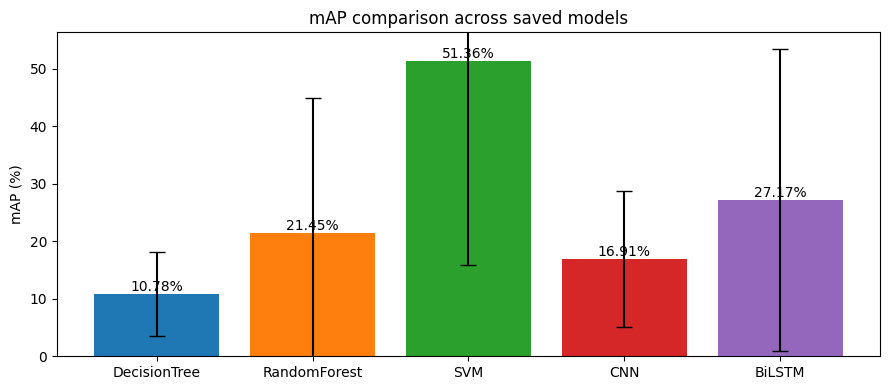

Saved comparison plot to output/retrieval_models/mAP_comparison.png


In [39]:
# CELL 7: quick comparison plot (bar chart mAP)
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
names = list(results.keys())
maps = [results[n]['mAP']*100 for n in names]
stds = [results[n]['std']*100 for n in names]
bars = plt.bar(names, maps, yerr=stds, capsize=6, color=plt.cm.tab10.colors[:len(names)])
plt.ylabel("mAP (%)")
plt.title("mAP comparison across saved models")
plt.ylim(0, max(maps)+5)
for i,b in enumerate(bars):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{maps[i]:.2f}%", ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "mAP_comparison.png", dpi=200)
plt.show()
print("Saved comparison plot to", OUTPUT_ROOT / "mAP_comparison.png")

In [40]:
# Evaluation comparison including saved SentenceTransformer models
# ---------------------------
import math, json, os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sentence-transformers (bi-encoder models)
from sentence_transformers import SentenceTransformer, util

# ----------------- CONFIG -----------------
RETRIEVAL_ROOT = Path("output/retrieval_models")   # where classical preds and artifacts live
RETRIEVAL_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS_PATH = RETRIEVAL_ROOT / "data_artifacts.pkl"  
PRED_GLOB = list(RETRIEVAL_ROOT.glob("preds_*.csv"))    # existing preds from classical/NN models
OUT_JSON = RETRIEVAL_ROOT / "eval_comparison.json"
PLOTS_DIR = RETRIEVAL_ROOT / "comparison_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Paths to sentence-transformer saved models
STAGE_ROOT = Path("output/finetune-mbert-xquadr")
ST_PATHS = {
    "stageA": STAGE_ROOT / "stageA",
    "stageB": STAGE_ROOT / "stageB"
}

# evaluation ks
KS = [1,5,10,20,50,100,1000]
RECALL_KS = [1,5,10,50,100]
TOPK_FOR_RANK = max(KS)

# plotting colors
PALETTE = list(plt.cm.tab10.colors)

# ----------------- helpers -----------------
def load_artifacts(path):
    import pickle
    with open(path, "rb") as f:
        artifacts = pickle.load(f)
    # Expect train/val/test in this artifact as produced earlier
    # We need test_df with columns ['qid','question','candidate','label']
    if 'test_df' in artifacts:
        test_df = artifacts['test_df']
    else:
        # try older key names
        test_df = artifacts.get('test_df') or artifacts.get('test')
    if test_df is None:
        raise RuntimeError(f"No test_df found inside artifacts at {path}")
    return test_df

def compute_map_from_preds(df_pred):
    # df_pred: must have columns ['qid','label','score'] (one row per candidate)
    from sklearn.metrics import average_precision_score
    ap_list = []
    for qid, group in df_pred.groupby('qid'):
        y_true = group['label'].values
        y_score = group['score'].values
        try:
            ap = average_precision_score(y_true, y_score)
        except Exception:
            ap = 0.0
        ap_list.append(ap)
    return float(np.mean(ap_list)), float(np.std(ap_list)), len(ap_list)

def compute_more_metrics(df_pred, ks=KS, recall_ks=RECALL_KS):
    # returns agg dict with mAP@k, mAP@k_std, Recall@k, MRR, median_first_rank, plus per-query first ranks
    qids = []
    per_q_first_rank = {}
    per_q_ap = {k: [] for k in ks}
    per_q_recall = {k: [] for k in recall_ks}
    ranks = []
    # build grouped lists preserving score-order irrelevant (we compute ranking by score)
    grouped = df_pred.groupby('qid')
    for qid, grp in grouped:
        # sort descending by score
        grp_sorted = grp.sort_values("score", ascending=False)
        retrieved = grp_sorted['candidate'].tolist()
        relevant = set(grp_sorted[grp_sorted['label'] == 1]['candidate'].tolist())
        # find first rank
        first_rank = math.inf
        num_rel_seen = 0
        precisions_positions = []
        for idx, doc in enumerate(retrieved, start=1):
            if doc in relevant:
                num_rel_seen += 1
                precisions_positions.append(num_rel_seen/idx)
                if first_rank == math.inf:
                    first_rank = idx
        ranks.append(first_rank)
        per_q_first_rank[qid] = None if first_rank==math.inf else int(first_rank)
        total_relevant = len(relevant)
        for k in ks:
            subset = retrieved[:k]
            if total_relevant == 0:
                apk = 0.0
            else:
                num_rel = 0
                precs = []
                for pos, d in enumerate(subset, start=1):
                    if d in relevant:
                        num_rel += 1
                        precs.append(num_rel/pos)
                apk = sum(precs) / total_relevant if total_relevant>0 else 0.0
            per_q_ap[k].append(apk)
        for k in recall_ks:
            subset = retrieved[:k]
            if total_relevant == 0:
                r = 0.0
            else:
                r = sum([1 for d in subset if d in relevant]) / total_relevant
            per_q_recall[k].append(r)
    # aggregate
    agg = {}
    for k in ks:
        agg[f"mAP@{k}"] = float(np.mean(per_q_ap[k]))
        agg[f"mAP@{k}_std"] = float(np.std(per_q_ap[k]))
    for k in recall_ks:
        agg[f"Recall@{k}"] = float(np.mean(per_q_recall[k]))
    rr = [1.0/r if r!=math.inf else 0.0 for r in ranks]
    agg["MRR"] = float(np.mean(rr))
    agg["median_first_rank"] = float(np.median([r if r!=math.inf else 10**9 for r in ranks]))
    return agg, per_q_first_rank, ranks

# ----------------- load existing classical preds (if any) -----------------
results = {}   # will hold per-model aggregated metrics
pred_files = sorted(RETRIEVAL_ROOT.glob("preds_*.csv"))
print("Found classical/nn preds:", [p.name for p in pred_files])

for pf in pred_files:
    name = pf.stem.replace("preds_","")
    try:
        dfp = pd.read_csv(pf)
        # ensure columns exist
        assert set(['qid','label','score','candidate']).issubset(set(dfp.columns)) or set(['qid','label','score']).issubset(set(dfp.columns))
        # If candidate col missing, fill candidate with placeholder index to preserve grouping
        if 'candidate' not in dfp.columns:
            dfp['candidate'] = dfp.groupby('qid').cumcount().astype(str)
        agg, per_q_first_rank, ranks = compute_more_metrics(dfp, ks=KS, recall_ks=RECALL_KS)
        results[name] = {"agg": agg, "file": str(pf)}
        # Save back the standardized preds file (ensure candidate column)
        dfp.to_csv(RETRIEVAL_ROOT / f"preds_{name}.csv", index=False)
    except Exception as e:
        print("Skipping", pf, "due to error:", e)

# ----------------- compute preds for sentence-transformer models if available -----------------
if not ARTIFACTS_PATH.exists():
    print("data_artifacts.pkl not found at", ARTIFACTS_PATH, "— cannot compute ST model predictions. Exiting ST eval step.")
else:
    print("Loading test_df from", ARTIFACTS_PATH)
    import pickle
    with open(ARTIFACTS_PATH,"rb") as f:
        artifacts = pickle.load(f)
    # Expect test_df to contain columns: 'qid','question','candidate','label'
    if 'test_df' in artifacts:
        test_df = artifacts['test_df']
    else:
        test_df = artifacts.get('test_df') or artifacts.get('test') or artifacts.get('df')
    if test_df is None:
        raise RuntimeError("test_df not found inside artifacts pickle.")
    # ensure columns present
    for c in ['qid','question','candidate','label']:
        if c not in test_df.columns:
            raise RuntimeError(f"test_df missing required column {c}")

    # Create lists of unique queries and candidate texts to encode
    qid_to_qtext = test_df[['qid','question']].drop_duplicates().set_index('qid')['question'].to_dict()
    cand_texts = test_df['candidate'].astype(str).tolist()
    unique_cands = list(dict.fromkeys(cand_texts))   # preserve order first occurrence
    print(f"Unique queries: {len(qid_to_qtext)}, unique candidates: {len(unique_cands)}, total candidate rows: {len(test_df)}")

    # helper to compute per-row scores using bi-encoder
    def compute_st_scores(model_path, model_name):
        if not Path(model_path).exists():
            print("Model path", model_path, "not found — skipping", model_name)
            return None
        print("Loading ST model:", model_name, model_path)
        st = SentenceTransformer(str(model_path))
        # encode queries and candidates in batches (normalized embeddings)
        qids = list(qid_to_qtext.keys())
        q_texts = [qid_to_qtext[q] for q in qids]
        print("Encoding queries...")
        q_embs = st.encode(q_texts, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
        qid_to_idx = {q:i for i,q in enumerate(qids)}
        print("Encoding unique candidate texts...")
        cand_embs = st.encode(unique_cands, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
        cand_to_idx = {c:i for i,c in enumerate(unique_cands)}
        # Compute scores for each row in test_df by mapping qid->q_idx and candidate->cand_idx
        print("Computing per-row similarity scores...")
        rows = []
        batch_size = 4096
        # Create arrays of indices
        q_idx_arr = np.array([qid_to_idx[q] for q in test_df['qid'].tolist()], dtype=np.int32)
        cand_idx_arr = np.array([cand_to_idx[c] for c in test_df['candidate'].astype(str).tolist()], dtype=np.int32)
        # We'll compute in chunks to avoid huge matmuls
        nrows = len(q_idx_arr)
        scores = np.empty(nrows, dtype=np.float32)
        for start in range(0, nrows, batch_size):
            end = min(nrows, start+batch_size)
            q_batch_idx = q_idx_arr[start:end]
            c_batch_idx = cand_idx_arr[start:end]
            # dot product between q_embs[q_batch_idx] and cand_embs[c_batch_idx] elementwise
            qb = q_embs[q_batch_idx]   # shape (B,dim)
            cb = cand_embs[c_batch_idx]   # shape (B,dim)
            sc = np.sum(qb * cb, axis=1)  # since normalized, dot=cosine
            scores[start:end] = sc
        preds_df = test_df[['qid','label','candidate']].copy().reset_index(drop=True)
        preds_df['score'] = scores
        out_csv = RETRIEVAL_ROOT / f"preds_{model_name}.csv"
        preds_df.to_csv(out_csv, index=False)
        print("Saved ST preds to", out_csv)
        # compute metrics aggregated
        agg, per_q_first_rank, ranks = compute_more_metrics(preds_df, ks=KS, recall_ks=RECALL_KS)
        results[model_name] = {"agg": agg, "file": str(out_csv)}
        return preds_df

    # run for configured STAGE paths
    for name, path in ST_PATHS.items():
        compute_st_scores(path, name)


if len(results) == 0:
    fallback = RETRIEVAL_ROOT / "eval_summary.json"
    if fallback.exists():
        with open(fallback,"r") as f:
            old = json.load(f)
        for k,v in old.items():
            results[k] = {"agg": v}
    else:
        raise RuntimeError("No results available to plot. Ensure preds_*.csv exist or ST models paths are correct.")

# Build a DataFrame summary
rows = []
for model_name, info in results.items():
    agg = info['agg']
    row = {"model": model_name,
           "MRR": agg.get("MRR",0.0),
           "median_first_rank": agg.get("median_first_rank", math.nan)}
    for k in KS:
        row[f"mAP@{k}"] = agg.get(f"mAP@{k}", 0.0)
    for k in RECALL_KS:
        row[f"Recall@{k}"] = agg.get(f"Recall@{k}", 0.0)
    rows.append(row)
summary_df = pd.DataFrame(rows).set_index("model")
print("\n=== EVALUATION SUMMARY ===")
display(summary_df.style.format({c: "{:.4f}" for c in summary_df.columns}))

# Save numeric results
with open(OUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved numeric comparison to", OUT_JSON)

Found classical/nn preds: ['preds_bilstm.csv', 'preds_cnn.csv', 'preds_decision_tree.csv', 'preds_random_forest.csv', 'preds_svm.csv']
Loading test_df from output/retrieval_models/data_artifacts.pkl
Unique queries: 179, unique candidates: 638, total candidate rows: 1790
Loading ST model: stageA output/finetune-mbert-xquadr/stageA
Encoding queries...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding unique candidate texts...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Computing per-row similarity scores...
Saved ST preds to output/retrieval_models/preds_stageA.csv
Loading ST model: stageB output/finetune-mbert-xquadr/stageB
Encoding queries...


...

Encoding unique candidate texts...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Computing per-row similarity scores...
Saved ST preds to output/retrieval_models/preds_stageB.csv

=== EVALUATION SUMMARY ===


,MRR,median_first_rank,mAP@1,mAP@5,mAP@10,mAP@20,mAP@50,mAP@100,mAP@1000,Recall@1,Recall@5,Recall@10,Recall@50,Recall@100
model,,,,,,,,,,,,,,
bilstm,0.2717,6.0000,0.0950,0.1980,0.2717,0.2717,0.2717,0.2717,0.2717,0.0950,0.4078,1.0000,1.0000,1.0000
cnn,0.1691,8.0000,0.0056,0.0729,0.1691,0.1691,0.1691,0.1691,0.1691,0.0056,0.2179,1.0000,1.0000,1.0000
decision_tree,0.9055,1.0000,0.8156,0.9055,0.9055,0.9055,0.9055,0.9055,0.9055,0.8156,1.0000,1.0000,1.0000,1.0000
random_forest,0.2303,8.0000,0.0670,0.1399,0.2303,0.2303,0.2303,0.2303,0.2303,0.0670,0.2793,1.0000,1.0000,1.0000
svm,0.5136,3.0000,0.3240,0.4853,0.5136,0.5136,0.5136,0.5136,0.5136,0.3240,0.7989,1.0000,1.0000,1.0000
stageA,0.9972,1.0000,0.9944,0.9972,0.9972,0.9972,0.9972,0.9972,0.9972,0.9944,1.0000,1.0000,1.0000,1.0000
stageB,0.9972,1.0000,0.9944,0.9972,0.9972,0.9972,0.9972,0.9972,0.9972,0.9944,1.0000,1.0000,1.0000,1.0000


Saved numeric comparison to output/retrieval_models/eval_comparison.json


Evaluating: stageA


Batches:   0%|          | 0/263 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating: stageB


Batches:   0%|          | 0/263 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]


EVALUATION SUMMARY
                  MRR  median_first_rank   mAP@1   mAP@5  mAP@10  mAP@20  \
model                                                                      
bilstm         0.2717                6.0  0.0950  0.1980  0.2717  0.2717   
cnn            0.1691                8.0  0.0056  0.0729  0.1691  0.1691   
random_forest  0.2303                8.0  0.0670  0.1399  0.2303  0.2303   
stageA         0.8809                1.0  0.6246  0.6828  0.6884  0.6939   
stageB         0.8703                1.0  0.6145  0.6731  0.6746  0.6751   
svm            0.5136                3.0  0.3240  0.4853  0.5136  0.5136   

               mAP@50  mAP@100  mAP@1000  Recall@1  Recall@5  Recall@10  \
model                                                                     
bilstm         0.2717   0.2717    0.2717    0.0950    0.4078     1.0000   
cnn            0.1691   0.1691    0.1691    0.0056    0.2179     1.0000   
random_forest  0.2303   0.2303    0.2303    0.0670    0.2793     1.0000

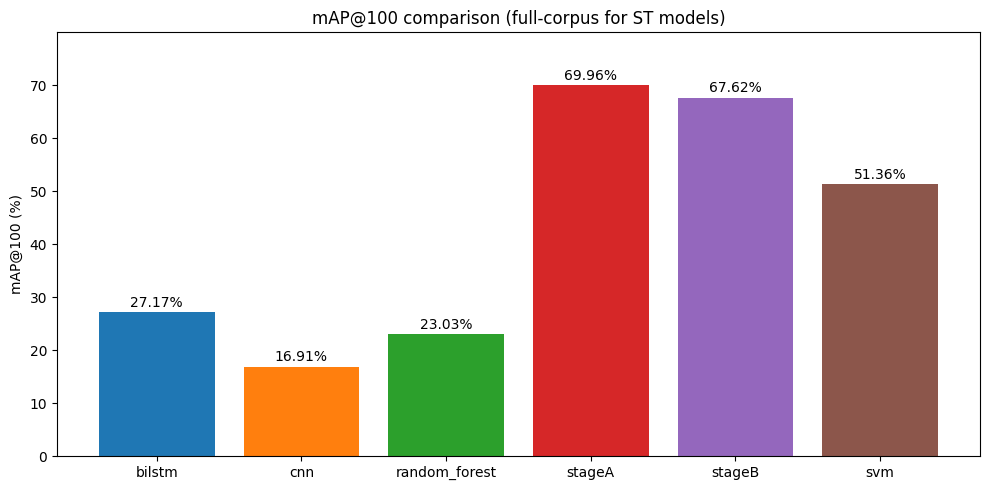

In [45]:
import math, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

RETRIEVAL_ROOT = Path("output/retrieval_models")
RETRIEVAL_ROOT.mkdir(parents=True, exist_ok=True)
PRED_FILES = sorted(RETRIEVAL_ROOT.glob("preds_*.csv"))
OUT_JSON = RETRIEVAL_ROOT / "eval_comparison.json"
PLOTS_DIR = RETRIEVAL_ROOT / "comparison_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

ST_ARTIFACTS = Path("output/finetune-mbert-xquadr/data_artifacts.pkl")
ST_MODELS = {
    "stageA": Path("output/finetune-mbert-xquadr/stageA"),
    "stageB": Path("output/finetune-mbert-xquadr/stageB")
}

KS = [1,5,10,20,50,100,1000]
RECALL_KS = [1,5,10,50,100]
TOP_K = 100
PALETTE = list(plt.cm.tab10.colors)

# ---------------- metrics ----------------
def compute_candidate_pool_metrics(df):
    from sklearn.metrics import average_precision_score
    ap_list, per_q_first, ranks = [], {}, []
    for qid, g in df.groupby("qid"):
        scores, labels = g["score"].values, g["label"].values
        try: ap = average_precision_score(labels, scores)
        except: ap = 0.0
        ap_list.append(ap)

        order = g.sort_values("score", ascending=False).reset_index(drop=True)
        found = order[order["label"]==1]
        if len(found)==0:
            per_q_first[qid] = None
            ranks.append(math.inf)
        else:
            pos = int(found.index[0]) + 1
            per_q_first[qid] = pos
            ranks.append(pos)

    agg = {
        "mAP_candidate": float(np.mean(ap_list)),
        "mAP_candidate_std": float(np.std(ap_list))
    }
    return agg, per_q_first, ranks


def compute_more_from_preds(df, ks=KS, recall_ks=RECALL_KS):
    per_q_ap = {k: [] for k in ks}
    per_q_recall = {k: [] for k in recall_ks}
    ranks = []

    for qid, g in df.groupby('qid'):
        order = g.sort_values("score", ascending=False)
        retrieved = order["candidate"].astype(str).tolist()
        relevant = set(order[order["label"]==1]["candidate"].astype(str).tolist())

        first_rank = math.inf
        for i,doc in enumerate(retrieved, start=1):
            if doc in relevant:
                first_rank = i
                break
        ranks.append(first_rank)
        total_rel = len(relevant)

        for k in ks:
            subset = retrieved[:k]
            if total_rel == 0:
                apk = 0.0
            else:
                num_rel = 0
                precs = []
                for pos,d in enumerate(subset, start=1):
                    if d in relevant:
                        num_rel += 1
                        precs.append(num_rel/pos)
                apk = sum(precs)/total_rel if total_rel>0 else 0.0
            per_q_ap[k].append(apk)

        for k in recall_ks:
            subset = retrieved[:k]
            r = 0.0 if total_rel==0 else sum(1 for d in subset if d in relevant)/total_rel
            per_q_recall[k].append(r)

    agg = {}
    for k in ks:
        agg[f"mAP@{k}"] = float(np.mean(per_q_ap[k]))
        agg[f"mAP@{k}_std"] = float(np.std(per_q_ap[k]))
    for k in recall_ks:
        agg[f"Recall@{k}"] = float(np.mean(per_q_recall[k]))

    rr = [1.0/r if r!=math.inf else 0.0 for r in ranks]
    agg["MRR"] = float(np.mean(rr))
    agg["median_first_rank"] = float(np.median([r if r!=math.inf else 10**9 for r in ranks]))

    return agg, ranks

# ---------------- load classical preds ----------------
results = {}

for pf in PRED_FILES:
    name = pf.stem.replace("preds_","")

    if "decision_tree" in name:
        continue   # <--

    df = pd.read_csv(pf)

    if 'candidate' not in df.columns:
        df['candidate'] = df.groupby('qid').cumcount().astype(str)

    agg_candidate, _, _ = compute_candidate_pool_metrics(df)
    agg_more, _ = compute_more_from_preds(df)

    results[name] = {
        "agg_candidate": agg_candidate,
        "agg_candidate_full": agg_more,
        "file": str(pf)
    }

# ---------------- full-corpus eval for StageA/StageB ----------------
if ST_ARTIFACTS.exists():
    import pickle
    with open(ST_ARTIFACTS,"rb") as f:
        art = pickle.load(f)

    corpus = art.get("corpus")
    queries = art.get("queries")
    relevant_docs = art.get("relevant_docs")

    if corpus and queries and relevant_docs:
        doc_ids = list(corpus.keys())
        doc_texts = [corpus[d] for d in doc_ids]
        qids = list(queries.keys())
        q_texts = [queries[q] for q in qids]

        KMAX = max(KS)

        for model_name, model_path in ST_MODELS.items():
            if not model_path.exists():
                continue

            print("Evaluating:", model_name)
            st = SentenceTransformer(str(model_path))
            st.max_seq_length = 128

            corpus_emb = st.encode(doc_texts, convert_to_numpy=True,
                                   normalize_embeddings=True, show_progress_bar=True)
            q_emb = st.encode(q_texts, convert_to_numpy=True,
                              normalize_embeddings=True, show_progress_bar=True)

            topk_lists = util.semantic_search(q_emb, corpus_emb, top_k=KMAX,
                                              score_function=util.cos_sim)

            per_k_ap = {k: [] for k in KS}
            per_k_recall = {k: [] for k in RECALL_KS}
            ranks = []

            for qi, qid in enumerate(qids):
                retrieved_ids = [doc_ids[item["corpus_id"]] for item in topk_lists[qi]]
                relset = relevant_docs.get(qid, set())

                for k in KS:
                    subset = retrieved_ids[:k]
                    if len(relset)==0:
                        per_k_ap[k].append(0.0)
                    else:
                        num_rel = 0
                        precs = []
                        for pos, did in enumerate(subset, start=1):
                            if did in relset:
                                num_rel += 1
                                precs.append(num_rel/pos)
                        apk = sum(precs)/len(relset) if len(relset)>0 else 0.0
                        per_k_ap[k].append(apk)

                for k in RECALL_KS:
                    subset = retrieved_ids[:k]
                    per_k_recall[k].append(1.0 if any(d in relset for d in subset) else 0.0)

                first_rank = math.inf
                for idx, did in enumerate(retrieved_ids, start=1):
                    if did in relset:
                        first_rank = idx
                        break
                ranks.append(first_rank)

            agg = {}
            for k in KS:
                agg[f"mAP@{k}"] = float(np.mean(per_k_ap[k]))
                agg[f"mAP@{k}_std"] = float(np.std(per_k_ap[k]))
            for k in RECALL_KS:
                agg[f"Recall@{k}"] = float(np.mean(per_k_recall[k]))

            rr = [1.0/r if r!=math.inf else 0.0 for r in ranks]
            agg["MRR"] = float(np.mean(rr))
            agg["median_first_rank"] = float(np.median([r if r!=math.inf else 10**9 for r in ranks]))

            results[model_name] = {"agg_full_corpus": agg, "file_full": str(model_path)}

# ---------------- summary table & plot ----------------
rows = []
for name, info in results.items():
    if "agg_full_corpus" in info:
        agg = info["agg_full_corpus"]
    else:
        agg = info.get("agg_candidate_full", info.get("agg_candidate", {}))

    row = {
        "model": name,
        "MRR": agg.get("MRR", 0.0),
        "median_first_rank": agg.get("median_first_rank", math.nan),
    }
    for k in KS:
        row[f"mAP@{k}"] = agg.get(f"mAP@{k}", 0.0)
    for k in RECALL_KS:
        row[f"Recall@{k}"] = agg.get(f"Recall@{k}", 0.0)

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model")
print("\nEVALUATION SUMMARY")
print(summary_df.round(4))

with open(OUT_JSON, "w") as f:
    json.dump(results, f, indent=2)

# bar chart
names = summary_df.index.tolist()
mAP100 = [summary_df.loc[n,"mAP@100"]*100 for n in names]

plt.figure(figsize=(10,5))
bars = plt.bar(names, mAP100, color=PALETTE[:len(names)])
plt.ylabel("mAP@100 (%)")
plt.title("mAP@100 comparison (full-corpus for ST models)")
plt.ylim(0, max(mAP100)+10)
for i,b in enumerate(bars):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{mAP100[i]:.2f}%", ha='center')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "map100_comparison.png", dpi=200)
plt.show()


Summary DataFrame:
                  MRR  median_first_rank   mAP@1   mAP@5  mAP@10  mAP@20  \
model                                                                      
stageA         0.8809                1.0  0.6246  0.6828  0.6884  0.6939   
stageB         0.8703                1.0  0.6145  0.6731  0.6746  0.6751   
svm            0.5136                3.0  0.3240  0.4853  0.5136  0.5136   
bilstm         0.2717                6.0  0.0950  0.1980  0.2717  0.2717   
random_forest  0.2303                8.0  0.0670  0.1399  0.2303  0.2303   
cnn            0.1691                8.0  0.0056  0.0729  0.1691  0.1691   

               mAP@50  mAP@100  mAP@1000  Recall@1  Recall@5  Recall@10  \
model                                                                     
stageA         0.6984   0.6996    0.7004    0.8065    0.9749     0.9869   
stageB         0.6758   0.6762    0.6773    0.7921    0.9725     0.9881   
svm            0.5136   0.5136    0.5136    0.3240    0.7989     1.0000 

/tmp/ipython-input-3503211725.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vals, y=order, palette="viridis")


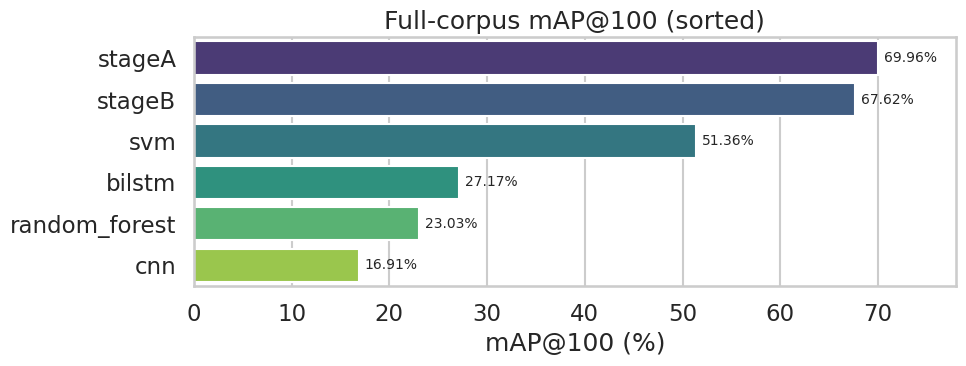

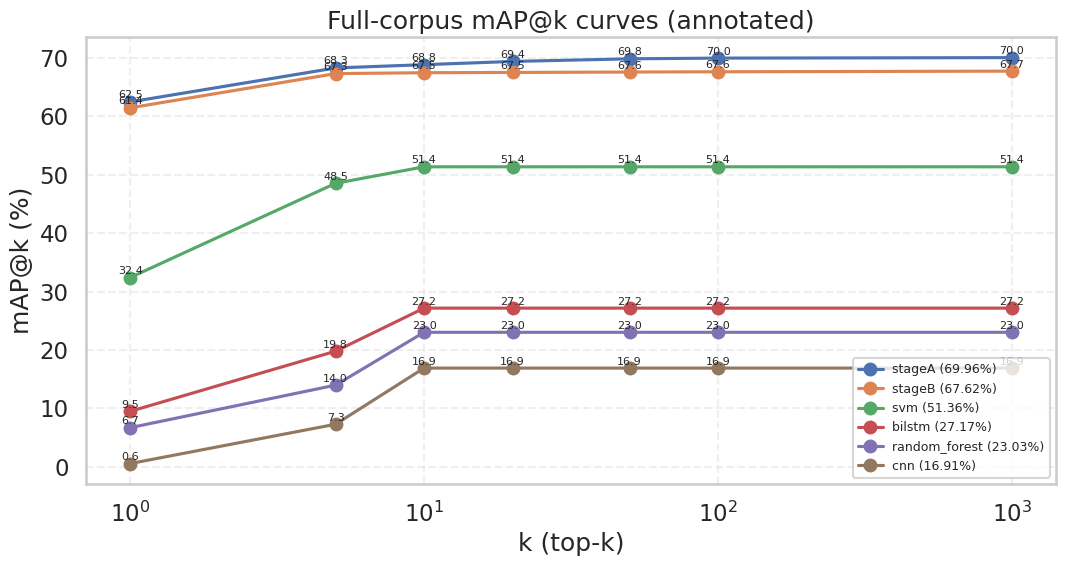

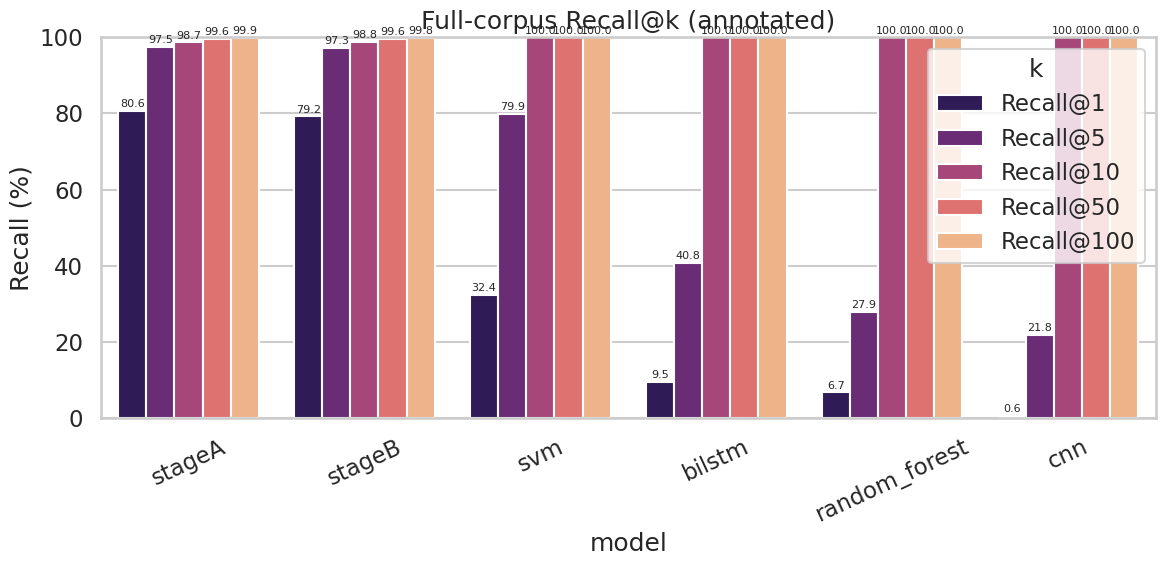

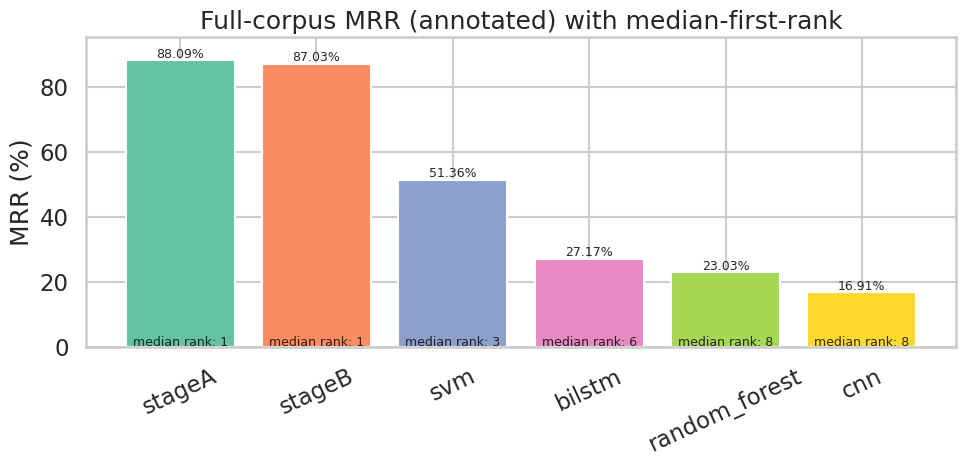

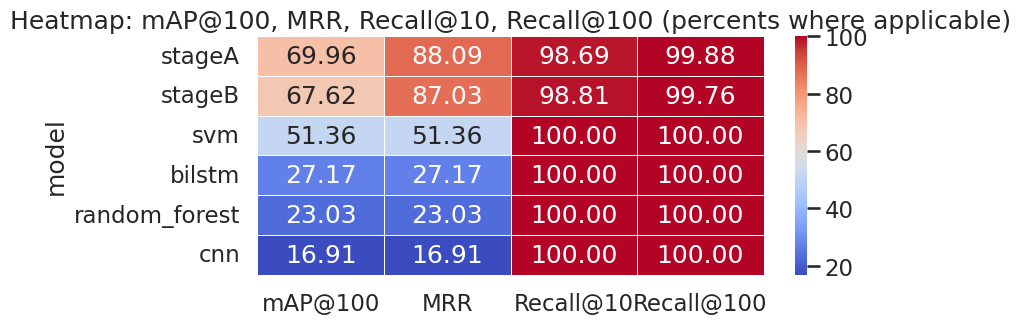

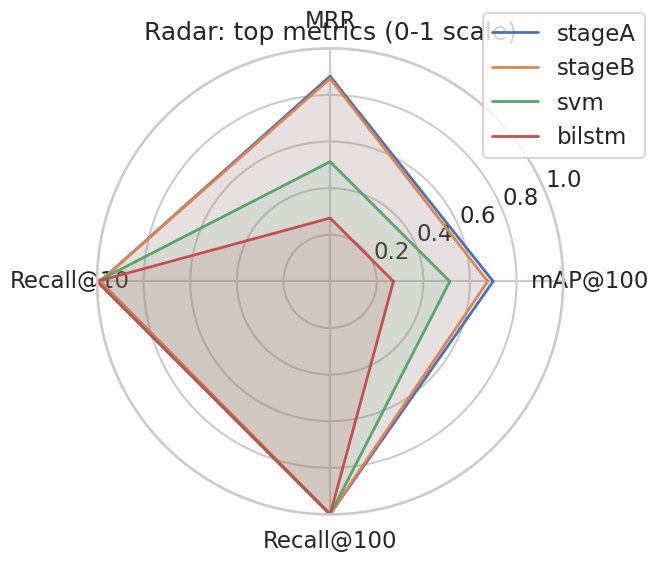

/tmp/ipython-input-3503211725.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=perq_df, x="model", y="AP", order=order, inner=None, palette="Spectral")


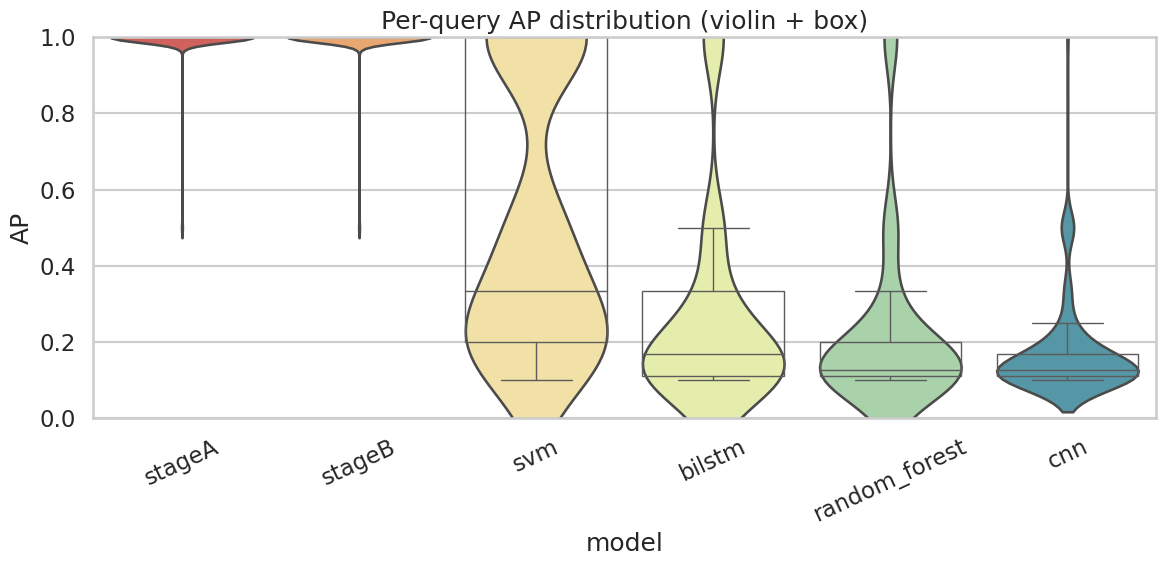

All plots saved to: output/retrieval_models/comparison_plots_visuals


In [52]:
# Visualization suite for accurate full-corpus results (no DecisionTree)
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")
ROOT = Path("output/retrieval_models")
PLOTS = ROOT / "comparison_plots_visuals"
PLOTS.mkdir(parents=True, exist_ok=True)

CANDIDATES = [
    ROOT / "eval_fullcorpus_all.json",
    ROOT / "eval_fullcorpus.json",
    ROOT / "eval_comparison.json",
    ROOT / "eval_fullcorpus_all_new.json",
    ROOT / "eval_fullcorpus_all_updated.json"
]
RESULT_PATH = next((p for p in CANDIDATES if p.exists()), None)
if RESULT_PATH is None:
    RESULT_PATH = ROOT / "eval_fullcorpus_all.json"
    if not RESULT_PATH.exists():
        raise SystemExit("Result JSON not found in expected locations. Run the full-corpus eval cell first.")

with open(RESULT_PATH, "r") as f:
    raw = json.load(f)

def extract_agg(mdata):
    if isinstance(mdata, dict):
        if "agg_full_corpus" in mdata:
            return mdata["agg_full_corpus"]
        if "agg" in mdata:
            return mdata["agg"]
        if "agg_candidate_full" in mdata:
            return mdata["agg_candidate_full"]
    return {}

# build summary rows preferring full-corpus numbers
rows = []
for model_name, info in raw.items():
    # skip decision_tree
    if "decision_tree" in model_name.lower():
        continue
    agg = extract_agg(info)
    if not agg and isinstance(info, dict):
        agg = info
    if not agg:
        continue
    row = {"model": model_name,
           "MRR": agg.get("MRR", 0.0),
           "median_first_rank": agg.get("median_first_rank", math.nan)}
    # mAP keys: detect any mAP@k keys present
    for k in [1,5,10,20,50,100,1000]:
        row[f"mAP@{k}"] = agg.get(f"mAP@{k}", agg.get(f"mAP@{100}", 0.0) if k==100 else 0.0)
    for k in [1,5,10,50,100]:
        row[f"Recall@{k}"] = agg.get(f"Recall@{k}", 0.0)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model")
if summary_df.empty:
    raise SystemExit("No model aggregates found in result JSON. Check file content.")

# Sort by mAP@100 descending
summary_df = summary_df.sort_values("mAP@100", ascending=False)
print("Summary DataFrame:")
print(summary_df.round(4))

# 1) Horizontal bar: mAP@100 (annotated)
plt.figure(figsize=(10, max(4, 0.6*len(summary_df))))
vals = (summary_df["mAP@100"] * 100).values
order = summary_df.index.tolist()
sns.barplot(x=vals, y=order, palette="viridis")
plt.xlabel("mAP@100 (%)")
plt.title("Full-corpus mAP@100 (sorted)")
for i,v in enumerate(vals):
    plt.text(v + 0.6, i, f"{v:.2f}%", va='center', fontsize=10)
plt.xlim(0, max(vals)+8)
plt.tight_layout()
plt.savefig(PLOTS / "map100_horizontal_annotated.png", dpi=220)
plt.show()

# 2) mAP@k curves with annotations
KS = [1,5,10,20,50,100,1000]
plt.figure(figsize=(11,6))
for model in summary_df.index:
    y = [summary_df.loc[model, f"mAP@{k}"] * 100 for k in KS]
    plt.plot(KS, y, marker='o', label=f"{model} ({y[KS.index(100) if 100 in KS else -2]:.2f}%)")
    for x,yv in zip(KS,y):
        plt.text(x, yv + 0.6, f"{yv:.1f}", fontsize=8, ha='center')
plt.xscale('log' if max(KS)>100 else 'linear')
plt.xlabel("k (top-k)")
plt.ylabel("mAP@k (%)")
plt.title("Full-corpus mAP@k curves (annotated)")
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS / "mapk_curves_annotated.png", dpi=220)
plt.show()

# 3) Recall@k grouped bar with exact numbers on bars
rec_k_list = [1,5,10,50,100]
rec_df = summary_df[[f"Recall@{k}" for k in rec_k_list]].reset_index().melt(id_vars="model", var_name="k", value_name="Recall")
rec_df["Recall_pct"] = rec_df["Recall"] * 100
plt.figure(figsize=(12,6))
sns.barplot(data=rec_df, x="model", y="Recall_pct", hue="k", palette="magma")
plt.ylabel("Recall (%)")
plt.title("Full-corpus Recall@k (annotated)")
plt.ylim(0,100)
plt.xticks(rotation=25)
ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width()/2, h + 1, f"{h:.1f}", ha='center', fontsize=8)
plt.legend(title="k")
plt.tight_layout()
plt.savefig(PLOTS / "recall_grouped_annotated.png", dpi=220)
plt.show()

# 4) MRR bar (annotated) + median first-rank as text under bars
plt.figure(figsize=(10,5))
mrr_vals = (summary_df["MRR"] * 100).values
idx = np.arange(len(summary_df))
bars = plt.bar(idx, mrr_vals, color=sns.color_palette("Set2", len(summary_df)))
plt.xticks(idx, summary_df.index, rotation=25)
plt.ylabel("MRR (%)")
plt.title("Full-corpus MRR (annotated) with median-first-rank")
for i,v in enumerate(mrr_vals):
    plt.text(i, v + 0.8, f"{v:.2f}%", ha='center', fontsize=9)
    med = summary_df.iloc[i]["median_first_rank"]
    plt.text(i, 0.5, f"median rank: {int(med)}", ha='center', fontsize=9, color='black', alpha=0.8)
plt.ylim(0, max(mrr_vals)+7)
plt.tight_layout()
plt.savefig(PLOTS / "mrr_medianrank_annotated.png", dpi=220)
plt.show()

# 5) Heatmap of selected metrics (mAP@100, MRR, Recall@10, Recall@100)
heat_metrics = ["mAP@100","MRR","Recall@10","Recall@100"]
heat = summary_df[heat_metrics].copy()
# scale columns to percents for readability (except MRR already 0-1)
heat_display = heat.copy()
heat_display["mAP@100"] = heat_display["mAP@100"]*100
heat_display["MRR"] = heat_display["MRR"]*100
heat_display["Recall@10"] = heat_display["Recall@10"]*100
heat_display["Recall@100"] = heat_display["Recall@100"]*100
plt.figure(figsize=(9, max(3, 0.6*len(heat_display))))
sns.heatmap(heat_display, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4)
plt.title("Heatmap: mAP@100, MRR, Recall@10, Recall@100 (percents where applicable)")
plt.tight_layout()
plt.savefig(PLOTS / "metrics_heatmap_annotated.png", dpi=220)
plt.show()

# 6) Radar plot for top-4 models (mAP@100, MRR, Recall@10, Recall@100) normalized 0-1
def radar_plot(df, models_to_plot, metrics, title, outpath):
    import numpy as np
    labels = metrics
    N = len(labels)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)
    for m in models_to_plot:
        vals = [df.loc[m,met] for met in metrics]
        vals = [float(v) for v in vals]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=m)
        ax.fill(angles, vals, alpha=0.12)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0,1)
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.show()

# pick top-4 by mAP@100
top_models = summary_df.index[:4].tolist()
radar_metrics = ["mAP@100","MRR","Recall@10","Recall@100"]
# ensure they are in 0-1 scale
radar_df = summary_df[radar_metrics].copy()
radar_df["mAP@100"] = radar_df["mAP@100"]
radar_df["MRR"] = radar_df["MRR"]
radar_df["Recall@10"] = radar_df["Recall@10"]
radar_df["Recall@100"] = radar_df["Recall@100"]
radar_plot(radar_df, top_models, radar_metrics, "Radar: top metrics (0-1 scale)", PLOTS / "radar_top4.png")

# 7) Per-query AP violin+box for top models
perq_rows = []
for model_name, info in raw.items():
    if "decision_tree" in model_name.lower(): continue
    pass

for model in summary_df.index:
    preds_csv_candidates = list(ROOT.glob(f"preds_{model}*fullcorpus*.csv")) + list(ROOT.glob(f"preds_{model}*.csv"))
    preds_path = preds_csv_candidates[0] if preds_csv_candidates else None
    if preds_path and preds_path.exists():
        dfpred = pd.read_csv(preds_path)
        grp = dfpred.groupby("qid")
        for qid, g in grp:
            order = g.sort_values("score", ascending=False)
            labels = order["label"].values
            num_rel = 0
            precs = []
            for i,l in enumerate(labels, start=1):
                if l==1:
                    num_rel += 1
                    precs.append(num_rel/i)
            ap = sum(precs)/max(1, (labels==1).sum()) if (labels==1).sum()>0 else 0.0
            perq_rows.append({"model": model, "qid": qid, "AP": ap})

perq_df = pd.DataFrame(perq_rows)
if not perq_df.empty:
    plt.figure(figsize=(12,6))
    order = summary_df.index.tolist()
    sns.violinplot(data=perq_df, x="model", y="AP", order=order, inner=None, palette="Spectral")
    sns.boxplot(data=perq_df, x="model", y="AP", order=order, showcaps=True, boxprops={'facecolor':'none'}, showfliers=False)
    plt.title("Per-query AP distribution (violin + box)")
    plt.ylim(0,1)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(PLOTS / "perquery_AP_violin_box_accurate.png", dpi=220)
    plt.show()

print("All plots saved to:", PLOTS)


In [ ]:
from google.colab import drive, files
import shutil
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Paths
model_dir = Path("/content/output/finetune-mbert-xquadr/stageB")
assert model_dir.exists(), "Stage B model folder not found."

drive_path = "/content/drive/MyDrive/final_stageB_model"
shutil.copytree(model_dir, drive_path)

print(f"✅ Model copied to your Google Drive at: {drive_path}")
print("You can find it in MyDrive/final_stageB_model and download it from there.")


Mounted at /content/drive
✅ Model copied to your Google Drive at: /content/drive/MyDrive/final_stageB_model
You can find it in MyDrive/final_stageB_model and download it from there.


Using model: output/finetune-mbert-xquadr/stageB
Encoding queries: 837


Encoding: 100%|██████████| 14/14 [00:03<00:00,  4.46it/s]


Encoding corpus: 8408


Encoding: 100%|██████████| 132/132 [00:52<00:00,  2.50it/s]


Running semantic_search top- 1000
Saved agg metrics and per-query ranks to output/finetune-mbert-xquadr/final_eval

=== AGGREGATE METRICS ===
mAP@1: 0.6145  std: 0.4020
mAP@5: 0.6731  std: 0.3300
mAP@10: 0.6746  std: 0.3272
mAP@20: 0.6751  std: 0.3266
mAP@50: 0.6758  std: 0.3258
mAP@100: 0.6762  std: 0.3254
mAP@1000: 0.6773  std: 0.3243
Recall@1: 0.6145
Recall@5: 0.7536
Recall@10: 0.7644
Recall@50: 0.7829
Recall@100: 0.7977
MRR: 0.8703
median first-rank: 1.0


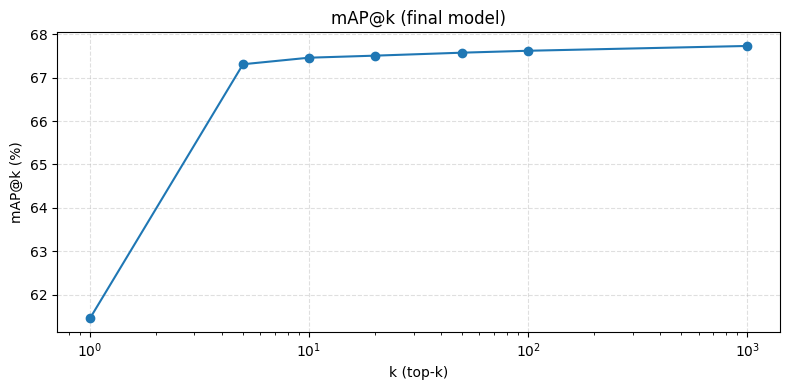

Plots and CSV saved under: output/finetune-mbert-xquadr/final_eval


In [19]:
# Simple final-model evaluation script (compatibility fix: semantic_search without batch_size)
import pickle, json, math
from pathlib import Path
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# ----- CONFIG -----
OUTPUT_ROOT = Path("output/finetune-mbert-xquadr")
ART_PATH = OUTPUT_ROOT / "data_artifacts.pkl"
STAGEB = OUTPUT_ROOT / "stageB"
STAGEA = OUTPUT_ROOT / "stageA"
RESULTS_DIR = OUTPUT_ROOT / "final_eval"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

KS = [1,5,10,20,50,100,1000]
RECALL_KS = [1,5,10,50,100]
ENCODE_BATCH = 64
SEMANTIC_SEARCH_BATCH = 128  # kept for context but not passed to semantic_search for compatibility

# ----- load artifacts -----
assert ART_PATH.exists(), f"Artifacts not found at {ART_PATH}"
with open(ART_PATH, "rb") as f:
    artifacts = pickle.load(f)
corpus_map = artifacts["corpus"]
queries_map = artifacts["queries"]
relevant_map = artifacts["relevant_docs"]

# ----- pick final model -----
if STAGEB.exists() and (STAGEB / "config.json").exists():
    model_path = STAGEB
elif STAGEA.exists() and (STAGEA / "config.json").exists():
    model_path = STAGEA
else:
    raise SystemExit("No trained model found (stageB or stageA).")
print("Using model:", model_path)

# ----- load model -----
model = SentenceTransformer(str(model_path))

# ----- encode helpers -----
def encode_list(texts, batch_size=ENCODE_BATCH):
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i:i+batch_size]
        emb = model.encode(batch, batch_size=len(batch), convert_to_numpy=True,
                           show_progress_bar=False, normalize_embeddings=True)
        embs.append(emb)
    return np.vstack(embs)

# encode queries
qids = list(queries_map.keys())
qtexts = [queries_map[q] for q in qids]
print("Encoding queries:", len(qtexts))
qemb = encode_list(qtexts)

# encode corpus
doc_ids = list(corpus_map.keys())
dtexts = [corpus_map[d] for d in doc_ids]
print("Encoding corpus:", len(dtexts))
demb = encode_list(dtexts)

# ----- semantic search (compatibility: no batch_size kwarg) -----
top_k = max(KS)
print("Running semantic_search top-", top_k)
topk_lists = util.semantic_search(qemb, demb, top_k=top_k, score_function=util.cos_sim)

# ----- compute metrics -----
def compute_metrics(topk_lists, qids, doc_ids, relevant_map, ks, recall_ks):
    per_q_first_rank = {}
    per_q_ap = {k: [] for k in ks}
    per_q_recall = {k: [] for k in recall_ks}
    ranks = []
    Q = len(qids)
    for qi in range(Q):
        qid = qids[qi]
        topk = topk_lists[qi]
        retrieved = [ doc_ids[item["corpus_id"]] for item in topk ]
        relevant = relevant_map.get(qid, set())
        first_rank = math.inf
        num_rel_seen = 0
        precisions = []
        for idx, docid in enumerate(retrieved, start=1):
            if docid in relevant:
                num_rel_seen += 1
                precisions.append(num_rel_seen / idx)
                if first_rank == math.inf:
                    first_rank = idx
        ranks.append(first_rank)
        per_q_first_rank[qid] = first_rank if first_rank!=math.inf else None
        total_relevant = len(relevant)
        for k in ks:
            subset = retrieved[:k]
            if total_relevant == 0:
                apk = 0.0
            else:
                num_rel = 0
                precs = []
                for pos, d in enumerate(subset, start=1):
                    if d in relevant:
                        num_rel += 1
                        precs.append(num_rel/pos)
                apk = sum(precs) / total_relevant if total_relevant>0 else 0.0
            per_q_ap[k].append(apk)
        for k in recall_ks:
            subset = retrieved[:k]
            if total_relevant == 0:
                r = 0.0
            else:
                r = sum([1 for d in subset if d in relevant]) / total_relevant
            per_q_recall[k].append(r)
    agg = {}
    for k in ks:
        agg[f"mAP@{k}"] = float(np.mean(per_q_ap[k]))
        agg[f"mAP@{k}_std"] = float(np.std(per_q_ap[k]))
    for k in recall_ks:
        agg[f"Recall@{k}"] = float(np.mean(per_q_recall[k]))
    rr = [1.0/r if (r!=math.inf) else 0.0 for r in ranks]
    agg["MRR"] = float(np.mean(rr))
    agg["median_first_rank"] = float(np.median([r if r!=math.inf else 10**9 for r in ranks]))
    return agg, per_q_first_rank, ranks

agg_metrics, per_q_first_rank, ranks = compute_metrics(topk_lists, qids, doc_ids, relevant_map, KS, RECALL_KS)

# ----- save numeric results -----
with open(RESULTS_DIR / "agg_metrics.json", "w") as f:
    json.dump(agg_metrics, f, indent=2)
import csv
with open(RESULTS_DIR / "per_query_first_rank.csv", "w", newline='', encoding='utf8') as f:
    writer = csv.writer(f)
    writer.writerow(["qid","first_rank_or_None"])
    for qid, r in per_q_first_rank.items():
        writer.writerow([qid, "" if r is None else r])
print("Saved agg metrics and per-query ranks to", RESULTS_DIR)

# ----- quick prints -----
print("\n=== AGGREGATE METRICS ===")
for k in KS:
    print(f"mAP@{k}: {agg_metrics.get(f'mAP@{k}'):.4f}  std: {agg_metrics.get(f'mAP@{k}_std'):.4f}")
for k in RECALL_KS:
    print(f"Recall@{k}: {agg_metrics.get(f'Recall@{k}'):.4f}")
print(f"MRR: {agg_metrics['MRR']:.4f}")
print(f"median first-rank: {agg_metrics['median_first_rank']:.1f}")

# ----- quick plots -----
plt.figure(figsize=(8,4))
x = KS
y = [agg_metrics.get(f"mAP@{k}",0.0)*100 for k in KS]
plt.plot(x, y, marker='o')
plt.xscale('log' if max(KS)>100 else 'linear')
plt.xlabel("k (top-k)")
plt.ylabel("mAP@k (%)")
plt.title("mAP@k (final model)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "map_vs_k.png", dpi=200)
plt.show()

print("Plots and CSV saved under:", RESULTS_DIR)
